In [1]:
import numpy as np
import torch, torchvision, torchaudio
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F

import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="torchaudio")

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import os
import json

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
torch.manual_seed(1337)
if torch.cuda.is_available():
    torch.cuda.manual_seed(1337)

if torch.cuda.is_available():
    major, minor = torch.cuda.get_device_capability()
    print(f"Compute Capability: {major}.{minor}")
    if major >= 8:
        print("✅ TF32 is supported (Ampere or newer).")
    else:
        print("❌ TF32 is not supported.")


torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

Using device: cuda
Compute Capability: 8.6
✅ TF32 is supported (Ampere or newer).


In [3]:
X = torch.rand((2, 1, 4))
dilation=2

X = F.pad(X, (dilation, 0))
print(X)

conv1d = nn.Conv1d(1, 1, 2, padding=0, dilation=dilation)
print(conv1d.weight)

w = conv1d.weight.detach().numpy()
b = conv1d.bias.detach().numpy()
x = X.numpy()
conv_x = conv1d(X)
print("w = ", w, "\nb = ", b)
print(f"Conv : {conv_x}\n")

x1 = x[0,0,:]
y = []
for i in range(len(x1) - dilation):
    print(f"{x1[i]}, {x1[i+dilation]}, * {w[0][0]} + {b[0]}, = \
        {np.sum([x1[i], x1[i+dilation]] * w[0][0]) + b[0]}")
    y.append(np.sum([x1[i], x1[i+dilation]] * w[0][0]) + b[0])
y = torch.Tensor(y)

print(y, conv_x[0][0])

tensor([[[0.0000, 0.0000, 0.0783, 0.4956, 0.6231, 0.4224]],

        [[0.0000, 0.0000, 0.2004, 0.0287, 0.5851, 0.6967]]])
Parameter containing:
tensor([[[-0.4580, -0.3401]]], requires_grad=True)
w =  [[[-0.45800862 -0.34008107]]] 
b =  [0.2949514]
Conv : tensor([[[ 0.2683,  0.1264,  0.0472, -0.0757]],

        [[ 0.2268,  0.2852,  0.0042,  0.0449]]],
       grad_fn=<ConvolutionBackward0>)

0.0, 0.07831710577011108, * [-0.45800862 -0.34008107] + 0.2949514091014862, =         0.26831725239753723
0.0, 0.49561673402786255, * [-0.45800862 -0.34008107] + 0.2949514091014862, =         0.12640154361724854
0.07831710577011108, 0.6230981349945068, * [-0.45800862 -0.34008107] + 0.2949514091014862, =         0.04717761278152466
0.49561673402786255, 0.4224381446838379, * [-0.45800862 -0.34008107] + 0.2949514091014862, =         -0.0757085382938385
tensor([ 0.2683,  0.1264,  0.0472, -0.0757]) tensor([ 0.2683,  0.1264,  0.0472, -0.0757], grad_fn=<SelectBackward0>)


Number of samples in dataset: 13100
Sample rate: 22050
Example utterance text: Printing, in the only sense with which we are at present concerned, differs from most if not from all the arts and crafts represented in the Exhibition
Waveform shape = torch.Size([1, 212893])


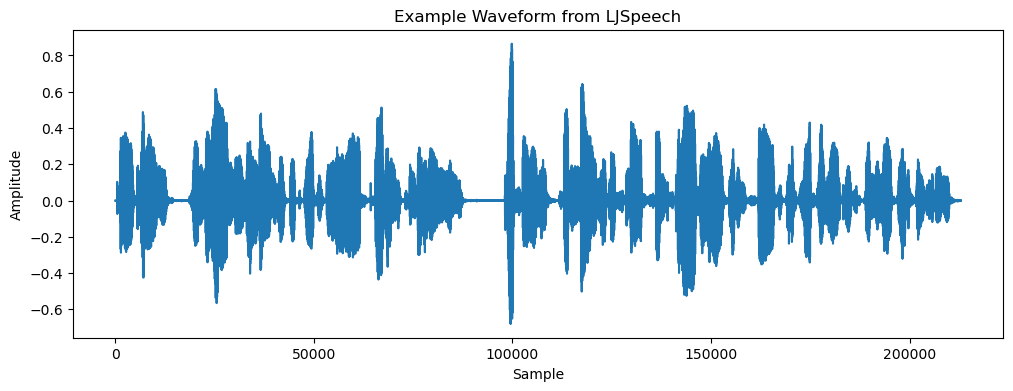

In [4]:
from IPython.display import Audio, display

# Load LJSpeech dataset.
# Each audio file is a single-channel 16-bit PCM WAV with a sample rate of 22050 Hz.
dataset = torchaudio.datasets.LJSPEECH(
    root="./data",
    download=True
)

# Print dataset info.
print(f"Number of samples in dataset: {len(dataset)}")
print(f"Sample rate: {dataset[0][1]}")
print(f"Example utterance text: {dataset[0][2]}")

# Get first audio sample and plot waveform.
waveform, sample_rate, _, _ = dataset[0]
print(f"Waveform shape = {waveform.shape}")
plt.figure(figsize=(12, 4))
plt.plot(waveform.t().numpy())
plt.title("Example Waveform from LJSpeech")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.show()

Audio(waveform.numpy(), rate=sample_rate)


In [5]:
config = {
    "batch_size": 4,
    "num_workers": 2,  # CHANGED: Use 0 for debugging, multiprocessing can cause issues
    "pin_memory": True,
    "mu": 255,
    "sr": 16000,  # CHANGED: Lower sample rate for faster processing
    "trim_silence_thresh": 1e-3,
    # Length of audio segments to train on in samples (not milliseconds)
    "window_size": 32001,  # ~2 seconds at 16kHz
    
    # Wavenet architecture related.
    "residual_channels": 64,
    "skip_channels": 256,
    "output_dim": 256,
    "n_layers": 10,
    "n_blocks": 3,
}

In [6]:
class MuLawEncoding:
    def __init__(self, mu=config['mu']):
        self.mu = mu

    def mu_law_encode(self, x):
        # x: torch [T] in [-1,1]
        y = torch.sign(x) * torch.log1p(self.mu * x.abs()) / torch.log1p(torch.tensor(self.mu))
        q = torch.clamp(((y + 1) / 2 * self.mu).long(), 0, int(self.mu))  # [T], int64 in [0,255]
        return q

    def mu_law_decode(self, q):
        # q: int tensor in [0,255]
        y = (q.float() / self.mu) * 2 - 1
        x_hat = torch.sign(y) * (1/self.mu) * ( (1+self.mu)**y.abs() - 1 )
        return x_hat

class AudioProcessor:
    def __init__(self):
        self.mu_law_encoding = MuLawEncoding()
        self.resamplers = {}  # Cache resamplers for efficiency

    def normalize(self, x):
        # Ensure audio is float32 and normalize to [-1, 1]
        if x.dtype != torch.float32:
            x = x.float()
        
        # peak normalization
        max_val = torch.max(torch.abs(x))
        if max_val > 0:  # Avoid division by zero
            x = x / max_val
        
        # rms normalization (optional)
        target_rms = 0.1
        def rms(x):
            return torch.sqrt(torch.mean(x**2) + 1e-8)
        current_rms = rms(x)
        if current_rms > 0:  # Avoid division by zero
            x = x * (target_rms / current_rms)

        return x

    def resample_audio(self, audio, orig_sr, target_sr):
        # FIXED: Properly handle sample rate conversion
        if orig_sr == target_sr:
            return audio
            
        # Use cached resampler for efficiency
        resampler_key = f"{orig_sr}_{target_sr}"
        if resampler_key not in self.resamplers:
            self.resamplers[resampler_key] = torchaudio.transforms.Resample(
                orig_freq=orig_sr,
                new_freq=target_sr
            )
        
        return self.resamplers[resampler_key](audio)

    # Trim leading/trailing silence
    def trim_silence(self, sig, thresh=config['trim_silence_thresh']):
        # sig: [1,T] tensor
        # returns: [1,T'] tensor with silence trimmed
        # Calculate energy
        energy = sig.abs().squeeze()
        # Find indices where energy is above threshold
        idx = torch.where(energy > thresh)[0]
        if len(idx) == 0:
            return sig  # Return original if no samples above threshold
        # Return trimmed signal
        return sig[:, idx[0].item():idx[-1].item() + 1]

    def segment_audio(self, audio):
        # Segments the audio into config['window_size'] segments. Pads the last segment with 0s if
        # required.
        # audio: [1,T] tensor
        # Returns: List of [1,window_size] tensors
        segments = []
        window_size = config['window_size']
        print(f"Audio shape: {audio.shape}")
        
        # Calculate number of complete segments
        num_segments = audio.shape[1] // window_size
        
        # Handle complete segments
        for i in range(num_segments):
            start = i * window_size
            end = start + window_size
            segments.append(audio[:, start:end])
            
        # Handle last incomplete segment if it exists
        remaining = audio.shape[1] % window_size
        if remaining > 0:
            last_segment = F.pad(
                audio[:, -remaining:],
                (0, window_size - remaining),
                mode='constant',
                value=0
            )
            segments.append(last_segment)
            
        return segments
        
    def collate_fn(self, batch):
        """
        Args:
            batch: list of tuples like (audio, sr, text, normalized_text)
                where audio is a torch.Tensor [1, T] (mono)

        Returns:
            x: LongTensor [B, T-1]  (input tokens)
            y: LongTensor [B, T-1]  (target tokens, shifted by +1)
        """
        x_list = []
        y_list = []

        # Process each item → fixed-length window → μ-law → (inp,tgt)
        for (audio, sr, text, normalized_text) in batch:
            # 1) resample → trim → normalize
            audio = self.resample_audio(audio, sr, config['sr'])  # [1, T']
            audio = self.trim_silence(audio)                      # [1, T'']
            audio = self.normalize(audio)                         # [1, T'']

            # (optional) downmix if stereo slipped through
            if audio.size(0) > 1:
                audio = audio.mean(dim=0, keepdim=True)          # [1, T'']

            # 2) ensure minimum length, crop to window
            if audio.shape[1] < config['window_size']:
                continue
            audio = audio[:, :config['window_size']]              # [1, W]

            # 3) μ-law encode → tokens [W]
            q = self.mu_law_encoding.mu_law_encode(audio.squeeze(0))  # [W] long

            # 4) build teacher-forced pair (shift by 1)
            x_tok = q[:-1]   # [W-1]
            y_tok = q[ 1:]   # [W-1]

            x_list.append(x_tok)
            y_list.append(y_tok)

        # If nothing survived filtering, return empty tensors
        if len(x_list) == 0:
            return (torch.empty(0, 0, dtype=torch.long),
                    torch.empty(0, 0, dtype=torch.long))

        # All items should already be same length (W-1). Still, be safe:
        max_len = max(t.size(0) for t in x_list)
        x = torch.stack([F.pad(t, (0, max_len - t.size(0)), value=0) for t in x_list], dim=0)  # [B, T-1]
        y = torch.stack([F.pad(t, (0, max_len - t.size(0)), value=0) for t in y_list], dim=0)  # [B, T-1]
        return x.long(), y.long()



In [7]:
from torch.utils.data import Subset

1# Split dataset into train and test sets (90-10 split)
train_size = int(0.9 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(
    dataset, 
    [train_size, test_size]
)
fake_train_dataset, fake_test_dataset = Subset(dataset, [0]), Subset(dataset, [0])

print(f"Training set size: {len(train_dataset)}")
print(f"Test set size: {len(test_dataset)}")
print(f"Fake training set size: {len(fake_train_dataset)}")
print(f"Fake test set size: {len(fake_test_dataset)}")

# Audio processor.
audio_processor = AudioProcessor()

# Create dataloaders
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=config['batch_size'],
    shuffle=True,
    num_workers=config['num_workers'],
    pin_memory=True,
    collate_fn=lambda batch: audio_processor.collate_fn(batch),
)
test_loader = torch.utils.data.DataLoader(
    test_dataset, 
    batch_size=config['batch_size'],
    shuffle=False,
    num_workers=config['num_workers'],
    pin_memory=True,
    collate_fn=lambda batch: audio_processor.collate_fn(batch),
)
print(f"Number of training batches: {len(train_loader)}")
print(f"Number of test batches: {len(test_loader)}")

def fake_collate_fn(batch):
    x, y = audio_processor.collate_fn(batch)
    return x[0].unsqueeze(0), y[0].unsqueeze(0)

fake_train_loader = torch.utils.data.DataLoader(
    fake_train_dataset,
    batch_size=1,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
    collate_fn=fake_collate_fn,
)
fake_test_loader = torch.utils.data.DataLoader(
    fake_test_dataset, 
    batch_size=1,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
    collate_fn=fake_collate_fn,
)



Training set size: 11790
Test set size: 1310
Fake training set size: 1
Fake test set size: 1
Number of training batches: 2948
Number of test batches: 328


In [8]:
# Get a sample from test dataset and check if encoding/decoding is working fine..
batch = next(iter(train_loader))
if len(batch) > 0:
    mu_law_encoded_audio, mu_law_encoded_audio_y = batch  # Get first item from batch
    
    mu_law_encoded_audio = mu_law_encoded_audio[0]
    mu_law_encoded_audio_y = mu_law_encoded_audio_y[0]
    
    print(f"Encoded audio shape: {mu_law_encoded_audio.shape}")
    print(f"Encoded audio type: {mu_law_encoded_audio.dtype}")
    print(f"Encoded audio range: [{mu_law_encoded_audio.min()}, {mu_law_encoded_audio.max()}]")
    print(f"Encoded audio y shape: {mu_law_encoded_audio_y.shape}")
    
    # FIXED: Decode the mu-law encoded audio before playing
    mu = MuLawEncoding()
    decoded_audio = mu.mu_law_decode(mu_law_encoded_audio)
    
    print(f"Decoded audio shape: {decoded_audio.shape}")
    print(f"Decoded audio range: [{decoded_audio.min():.6f}, {decoded_audio.max():.6f}]")
    
    # Play the decoded audio
    audio_for_playback = decoded_audio.squeeze().numpy()
    print(f"Audio for playback shape: {audio_for_playback.shape}")
    
    # Create and display the audio player
    audio_player = Audio(audio_for_playback, rate=config['sr'])
    display(audio_player)
else:
    print("No valid audio samples in batch - all were too short or filtered out")

Encoded audio shape: torch.Size([32000])
Encoded audio type: torch.int64
Encoded audio range: [5, 248]
Encoded audio y shape: torch.Size([32000])
Decoded audio shape: torch.Size([32000])
Decoded audio range: [-0.803795, 0.736506]
Audio for playback shape: (32000,)


In [9]:
class CausalDilatedConvolution(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=2, dilation=1):
        super().__init__()
        self.kernel_size = kernel_size
        self.dilation = dilation
        self.conv1d = nn.Conv1d(
            in_channels, 
            out_channels, 
            kernel_size=kernel_size, 
            dilation=dilation, 
            padding=0, 
            bias=True)
    
    def forward(self, x):
        if self.kernel_size > 1:
            x = F.pad(x, ((self.kernel_size - 1) * self.dilation, 0), mode='constant', value=0)
        # print(f"x tensor shape after padding: {x.shape}")
        return self.conv1d(x)

# Test the module.
# Get all audio samples from the batch and stack them into a single tensor.
batch = torch.stack([item[0].squeeze() for item in next(iter(train_loader))])
print(f"batch tensor shape: {batch.shape}")

module = CausalDilatedConvolution(64, 64, kernel_size=2, dilation=2).to(device)
embedding = nn.Embedding(256, 64)

batch = embedding(batch)
batch = batch.permute(0, 2, 1)
print(f"batch tensor shape after embedding: {batch.shape}")

output = module(batch.to(device))
print(f"output tensor shape: {output.shape}")
assert output.shape == batch.shape, "Output shape should be same as input shape."
    

batch tensor shape: torch.Size([2, 32000])
batch tensor shape after embedding: torch.Size([2, 64, 32000])
output tensor shape: torch.Size([2, 64, 32000])


In [10]:
class ResidualBlock(nn.Module):
    def __init__(self, C_res, C_skip, dilation=1):
        super().__init__()
        self.filter_conv = CausalDilatedConvolution(C_res, C_res, kernel_size=2, dilation=dilation)
        self.gate_conv = CausalDilatedConvolution(C_res, C_res, kernel_size=2, dilation=dilation)
        self.skip_conv1x1 = nn.Conv1d(C_res, C_skip, 1)
        self.res_conv1x1 = CausalDilatedConvolution(C_res, C_res, kernel_size=1, dilation=1)
        
    def forward(self, x):
        z = torch.tanh(self.filter_conv(x)) * torch.sigmoid(self.gate_conv(x))
        skip = self.skip_conv1x1(z)
        out = self.res_conv1x1(z)
        return out + x, skip

# Test the module.
# Get all audio samples from the batch and stack them into a single tensor.
batch = torch.stack([item[0].squeeze() for item in next(iter(train_loader))])
print(f"batch tensor shape: {batch.shape}")

module = ResidualBlock(64, 64, dilation=2).to(device)
embedding = nn.Embedding(256, 64)

batch = embedding(batch)
batch = batch.permute(0, 2, 1)
print(f"batch tensor shape after embedding: {batch.shape}")

output, skip = module(batch.to(device))
print(f"output tensor shape: {output.shape}")
print(f"skip tensor shape: {skip.shape}")
assert output.shape == batch.shape, "Output shape should be same as input shape."

batch tensor shape: torch.Size([2, 32000])
batch tensor shape after embedding: torch.Size([2, 64, 32000])
output tensor shape: torch.Size([2, 64, 32000])
skip tensor shape: torch.Size([2, 64, 32000])


In [11]:
class Wavenet(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.C_res  = config['residual_channels']
        self.C_output = config['output_dim']
        self.C_skip = config['skip_channels']
        self.K = config.get('kernel_size', 2)
        
        # Converts [B, T] to [B, T, C_res]
        self.embedding = nn.Embedding(self.C_output, self.C_res)
        
        self.conv1d = nn.Conv1d(self.C_res, self.C_res, kernel_size=1)
        self.residual_blocks = nn.ModuleList([
            self._create_residual_block(config) for i in range(config['n_blocks'])
        ])
        self.output_head = nn.Sequential(
            nn.ReLU(),
            nn.Conv1d(self.C_skip, self.C_skip, kernel_size=1),
            nn.ReLU(),
            nn.Conv1d(self.C_skip, self.C_output, kernel_size=1))
    
    def _create_residual_block(self, config):
        # Each residual block has n-layers with dilations = 1,2,4,8,...512
        return nn.ModuleList([
            ResidualBlock(self.C_res, self.C_skip, dilation=2**i)
            for i in range(config['n_layers'])
        ])

    def forward(self, x):
        x_embd = self.embedding(x)
        x_embd = x_embd.permute(0, 2, 1)
        skip_output = None
        
        # [B, C_hidden, T] as all convolutions expect this structure.
        x_embd = self.conv1d(x_embd)
        
        for residual_block in self.residual_blocks:
            for layer in residual_block:
                x_embd, x_skip = layer(x_embd)
                skip_output = x_skip if skip_output is None else skip_output + x_skip
            
        output = self.output_head(skip_output)
        
        # [B, T, C_output] again.
        output = output.permute(0, 2, 1)
        # output = torch.softmax(output, dim=2)
        return output

# Test the module.
# Get all audio samples from the batch and stack them into a single tensor.
batch = torch.stack([item[0].squeeze() for item in next(iter(train_loader))])
print(f"batch tensor shape: {batch.shape}")

module = Wavenet(config).to(device)
total_params = sum(p.numel() for p in module.parameters())
print(f"Total parameters: {total_params:,}")
print(f"Model size in GB: {(total_params * 4) / (1024**2):.2f} MB")  # Assuming float32 (4 bytes)
output = module(batch.to(device))
print(f"output tensor shape: {output.shape}")

batch tensor shape: torch.Size([2, 32000])
Total parameters: 1,271,488
Model size in GB: 4.85 MB
output tensor shape: torch.Size([2, 32000, 256])


In [ ]:
# Resumable Training Code - Copy this into a new notebook cell
# This version automatically loads the last checkpoint if it exists

# Fake dataset setup to test if training is working and is able to overfit on 1 sample.
USE_FAKE = True
if USE_FAKE:
    config['batch_size'] = 1
    config['num_workers'] = 0

# Training configuration
num_epochs = 20 if not USE_FAKE else 150  # 150 is enough to overfit completely.
learning_rate = 1e-3
checkpoint_dir = './wavenet_checkpoints_fake' if USE_FAKE else './wavenet_checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True)

train_loader = fake_train_loader if USE_FAKE else train_loader
test_loader = fake_test_loader if USE_FAKE else test_loader

# Initialize model and optimizer
model = Wavenet(config).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

# Tracking metrics
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
best_val_loss = float('inf')
start_epoch = 0

def save_checkpoint(epoch, model, optimizer, scheduler, train_losses, val_losses, 
                   train_accuracies, val_accuracies, best_val_loss, is_best=False):
    """Save checkpoint with all training state"""
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_accuracies': train_accuracies,
        'val_accuracies': val_accuracies,
        'best_val_loss': best_val_loss,
        'config': config,
        'learning_rate': learning_rate
    }
    
    # Save latest checkpoint
    latest_path = os.path.join(checkpoint_dir, 'latest_checkpoint.pth')
    torch.save(checkpoint, latest_path)
    
    # Save best model
    if is_best:
        best_path = os.path.join(checkpoint_dir, 'best_model.pth')
        torch.save(checkpoint, best_path)
        print(f"💾 New best model saved! Val Loss: {best_val_loss:.4f}")

def load_checkpoint(checkpoint_path, model, optimizer, scheduler):
    """Load checkpoint and restore training state"""
    try:
        print(f"🔄 Loading checkpoint from: {checkpoint_path}")
        checkpoint = torch.load(checkpoint_path, map_location=device)
        
        # Load model state
        model.load_state_dict(checkpoint['model_state_dict'])
        
        # Load optimizer state
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        
        # Load scheduler state
        if 'scheduler_state_dict' in checkpoint:
            scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
        
        # Load training metrics
        train_losses = checkpoint.get('train_losses', [])
        val_losses = checkpoint.get('val_losses', [])
        train_accuracies = checkpoint.get('train_accuracies', [])
        val_accuracies = checkpoint.get('val_accuracies', [])
        best_val_loss = checkpoint.get('best_val_loss', float('inf'))
        start_epoch = checkpoint.get('epoch', 0) + 1  # Start from next epoch
        
        print(f"✅ Checkpoint loaded successfully!")
        print(f"   Resuming from epoch {start_epoch}")
        print(f"   Best validation loss so far: {best_val_loss:.4f}")
        print(f"   Training history: {len(train_losses)} epochs")
        
        return start_epoch, train_losses, val_losses, train_accuracies, val_accuracies, best_val_loss
        
    except FileNotFoundError:
        print(f"❌ Checkpoint not found: {checkpoint_path}")
        print("🆕 Starting training from scratch")
        return 0, [], [], [], [], float('inf')
    except Exception as e:
        print(f"❌ Error loading checkpoint: {e}")
        print("🆕 Starting training from scratch")
        return 0, [], [], [], [], float('inf')

def find_latest_checkpoint(checkpoint_dir):
    """Find the most recent checkpoint"""
    latest_path = os.path.join(checkpoint_dir, 'latest_checkpoint.pth')
    best_path = os.path.join(checkpoint_dir, 'best_model.pth')
    
    # Check for latest checkpoint first
    if os.path.exists(latest_path):
        return latest_path
    # Fallback to best model if latest doesn't exist
    elif os.path.exists(best_path):
        print("⚠️  Latest checkpoint not found, loading best model instead")
        return best_path
    else:
        return None

# Try to load existing checkpoint
checkpoint_path = find_latest_checkpoint(checkpoint_dir)
if checkpoint_path:
    start_epoch, train_losses, val_losses, train_accuracies, val_accuracies, best_val_loss = \
        load_checkpoint(checkpoint_path, model, optimizer, scheduler)
else:
    print("🆕 No existing checkpoints found, starting fresh training")

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Starting/Resuming training from epoch {start_epoch+1} to {num_epochs}")

def prepare_batch(batch, device):
    """Prepare batch for autoregressive training"""
    audio_batch = torch.stack([item[0].squeeze() for item in batch]).to(device)
    audio_x = audio_batch[:, :-1]  # All but last timestep
    audio_y = audio_batch[:, 1:]   # All but first timestep (shifted by 1)
    return audio_x, audio_y

def calculate_accuracy(output, target):
    """Calculate prediction accuracy"""
    pred = torch.argmax(output, dim=-1)
    correct = (pred == target).sum().item()
    total = target.numel()
    return correct / total

def train_epoch(model, train_loader, optimizer, device):
    """Train for one epoch"""
    model.train()
    total_loss = 0.0
    total_accuracy = 0.0
    num_batches = 0
    
    pbar = tqdm(train_loader, desc="Training", leave=False)
    
    for batch in pbar:
        try:
            audio_x, audio_y = prepare_batch(batch, device)
            
            optimizer.zero_grad()
            output = model(audio_x)
            
            B, T, C = output.shape
            output_flat = output.reshape(-1, C)
            target_flat = audio_y.reshape(-1)
            
            loss = F.cross_entropy(output_flat, target_flat)
            accuracy = calculate_accuracy(output_flat, target_flat)
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            total_loss += loss.item()
            total_accuracy += accuracy
            num_batches += 1
            
            pbar.set_postfix({
                'Loss': f'{loss.item():.4f}',
                'Acc': f'{accuracy:.3f}'
            })
            
        except Exception as e:
            print(f"Error in training batch: {e}")
            continue
    
    return total_loss / max(num_batches, 1), total_accuracy / max(num_batches, 1)

def validate_epoch(model, test_loader, device):
    """Validate for one epoch"""
    model.eval()
    total_loss = 0.0
    total_accuracy = 0.0
    num_batches = 0
    
    with torch.no_grad():
        pbar = tqdm(test_loader, desc="Validation", leave=False)
        
        for batch in pbar:
            try:
                audio_x, audio_y = prepare_batch(batch, device)
                output = model(audio_x)
                
                B, T, C = output.shape
                output_flat = output.reshape(-1, C)
                target_flat = audio_y.reshape(-1)
                
                loss = F.cross_entropy(output_flat, target_flat)
                accuracy = calculate_accuracy(output_flat, target_flat)
                
                total_loss += loss.item()
                total_accuracy += accuracy
                num_batches += 1
                
                pbar.set_postfix({
                    'Val Loss': f'{loss.item():.4f}',
                    'Val Acc': f'{accuracy:.3f}'
                })
                
            except Exception as e:
                print(f"Error in validation batch: {e}")
                continue
    
    return total_loss / max(num_batches, 1), total_accuracy / max(num_batches, 1)

def plot_training_progress(train_losses, val_losses, train_accuracies, val_accuracies, epoch, checkpoint_dir):
    """Plot training progress with history"""
    if len(train_losses) == 0:
        return
    
    plt.figure(figsize=(15, 5))
    
    # Loss plot
    plt.subplot(1, 3, 1)
    epochs_range = range(1, len(train_losses) + 1)
    plt.plot(epochs_range, train_losses, 'b-', label='Training Loss', linewidth=2)
    plt.plot(epochs_range, val_losses, 'r-', label='Validation Loss', linewidth=2)
    plt.title(f'Training Progress (Epoch {epoch+1})')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Accuracy plot
    plt.subplot(1, 3, 2)
    plt.plot(epochs_range, train_accuracies, 'b-', label='Training Accuracy', linewidth=2)
    plt.plot(epochs_range, val_accuracies, 'r-', label='Validation Accuracy', linewidth=2)
    plt.title(f'Accuracy Progress (Epoch {epoch+1})')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Loss difference (overfitting indicator)
    plt.subplot(1, 3, 3)
    loss_diff = [v - t for t, v in zip(train_losses, val_losses)]
    plt.plot(epochs_range, loss_diff, 'g-', linewidth=2)
    plt.title('Overfitting Indicator (Val - Train Loss)')
    plt.xlabel('Epoch')
    plt.ylabel('Loss Difference')
    plt.axhline(y=0, color='k', linestyle='--', alpha=0.5)
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(checkpoint_dir, f'progress_epoch_{epoch+1}.png'), dpi=150)
    plt.show()


🔄 Loading checkpoint from: ./wavenet_checkpoints_fake/latest_checkpoint.pth
✅ Checkpoint loaded successfully!
   Resuming from epoch 20
   Best validation loss so far: 4.3206
   Training history: 20 epochs
Model parameters: 1,271,488
Starting/Resuming training from epoch 21 to 200



🚀 Resuming WaveNet Training
📊 Epochs: 21 → 200
💾 Checkpoints: ./wavenet_checkpoints_fake

Epoch 21/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 4.2643
Train Loss: 4.3206 | Train Acc: 0.077
Val Loss: 4.2643 | Val Acc: 0.081 🔥
LR: 0.001000


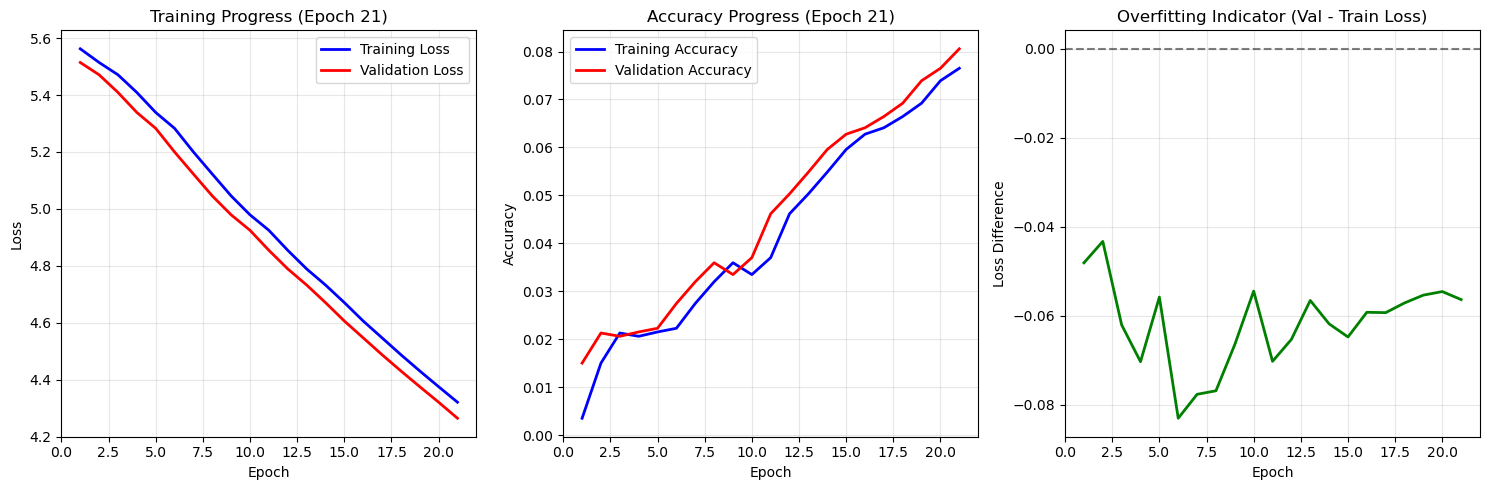


Epoch 22/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 4.2116
Train Loss: 4.2643 | Train Acc: 0.081
Val Loss: 4.2116 | Val Acc: 0.084 🔥
LR: 0.001000

Epoch 23/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 4.1174
Train Loss: 4.1636 | Train Acc: 0.088
Val Loss: 4.1174 | Val Acc: 0.093 🔥
LR: 0.001000

Epoch 25/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 4.0723
Train Loss: 4.1174 | Train Acc: 0.093
Val Loss: 4.0723 | Val Acc: 0.097 🔥
LR: 0.001000


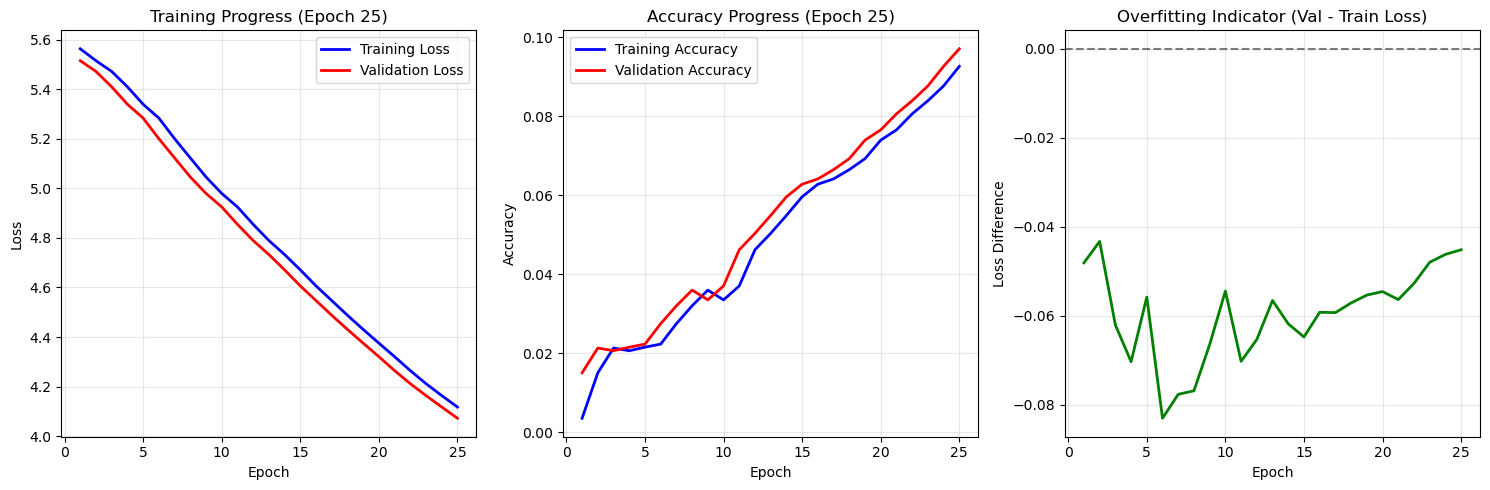


Epoch 26/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 4.0298
Train Loss: 4.0723 | Train Acc: 0.097
Val Loss: 4.0298 | Val Acc: 0.099 🔥
LR: 0.001000

Epoch 27/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 3.9050
Train Loss: 3.9471 | Train Acc: 0.104
Val Loss: 3.9050 | Val Acc: 0.108 🔥
LR: 0.001000

Epoch 30/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 3.8665
Train Loss: 3.9050 | Train Acc: 0.108
Val Loss: 3.8665 | Val Acc: 0.113 🔥
LR: 0.001000


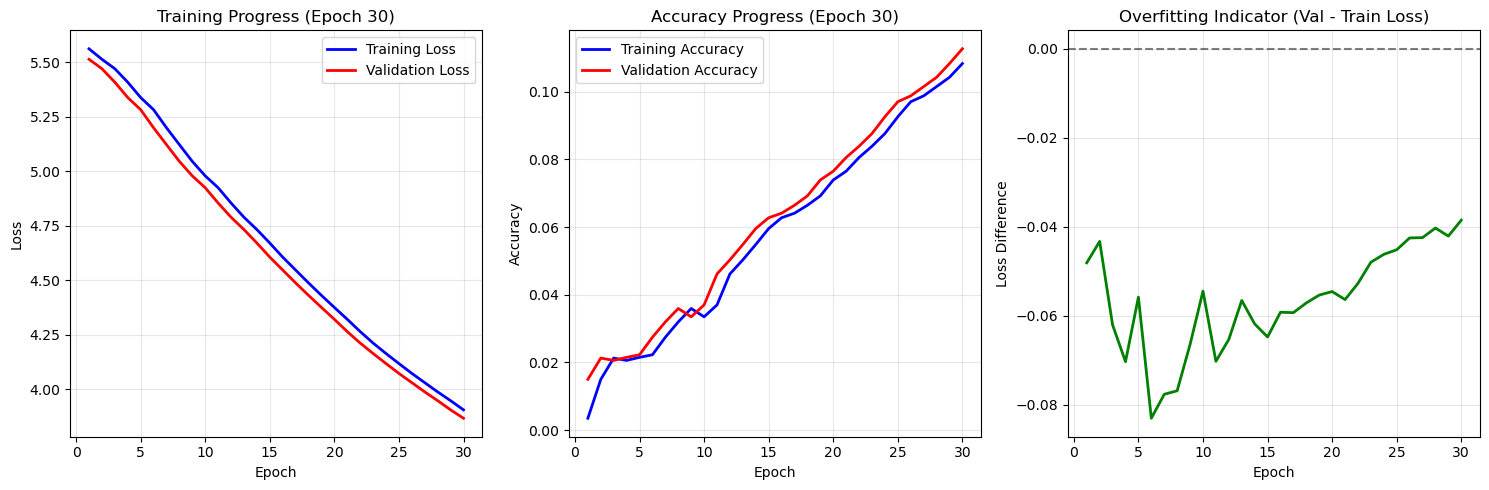


Epoch 31/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 3.8299
Train Loss: 3.8665 | Train Acc: 0.113
Val Loss: 3.8299 | Val Acc: 0.117 🔥
LR: 0.001000

Epoch 32/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 3.7233
Train Loss: 3.7592 | Train Acc: 0.125
Val Loss: 3.7233 | Val Acc: 0.132 🔥
LR: 0.001000

Epoch 35/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 3.6879
Train Loss: 3.7233 | Train Acc: 0.132
Val Loss: 3.6879 | Val Acc: 0.136 🔥
LR: 0.001000


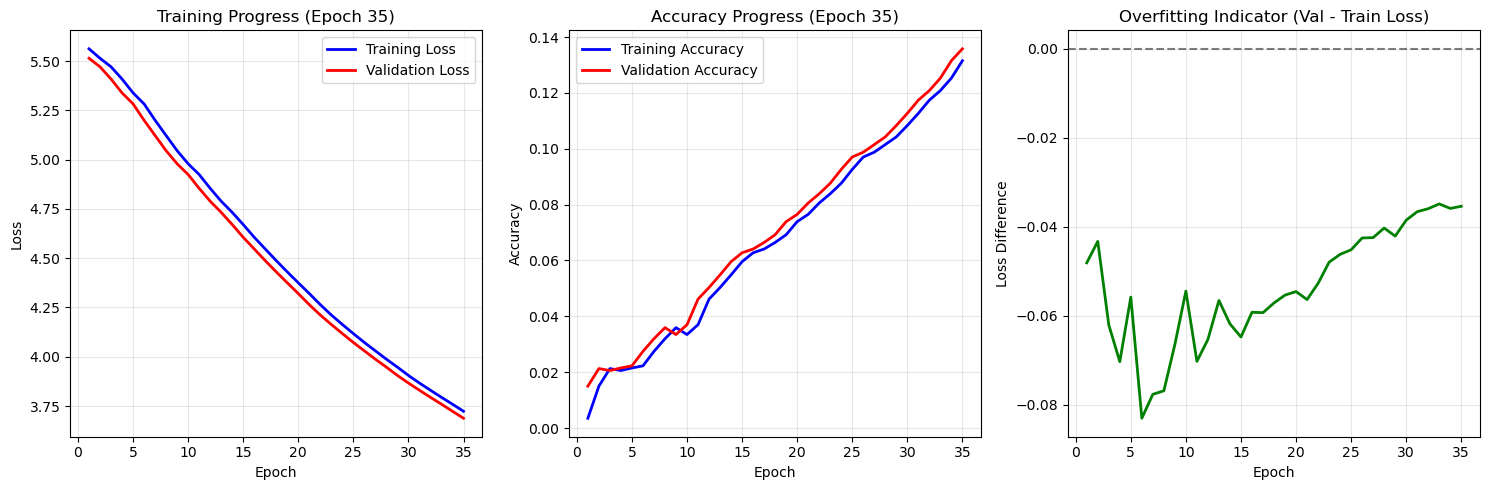


Epoch 36/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 3.6538
Train Loss: 3.6879 | Train Acc: 0.136
Val Loss: 3.6538 | Val Acc: 0.137 🔥
LR: 0.001000

Epoch 37/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 3.5496
Train Loss: 3.5830 | Train Acc: 0.149
Val Loss: 3.5496 | Val Acc: 0.155 🔥
LR: 0.001000

Epoch 40/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 3.5198
Train Loss: 3.5496 | Train Acc: 0.155
Val Loss: 3.5198 | Val Acc: 0.156 🔥
LR: 0.001000


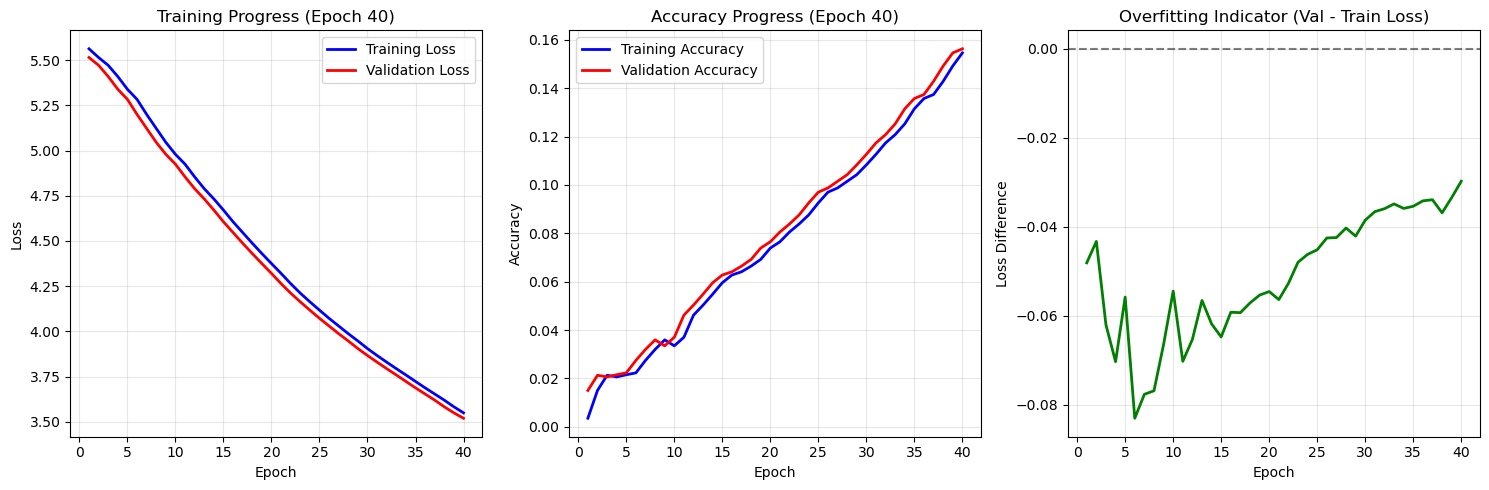


Epoch 41/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 3.4889
Train Loss: 3.5198 | Train Acc: 0.156
Val Loss: 3.4889 | Val Acc: 0.160 🔥
LR: 0.001000

Epoch 42/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 3.3828
Train Loss: 3.4156 | Train Acc: 0.173
Val Loss: 3.3828 | Val Acc: 0.178 🔥
LR: 0.001000

Epoch 45/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 3.3467
Train Loss: 3.3828 | Train Acc: 0.178
Val Loss: 3.3467 | Val Acc: 0.186 🔥
LR: 0.001000


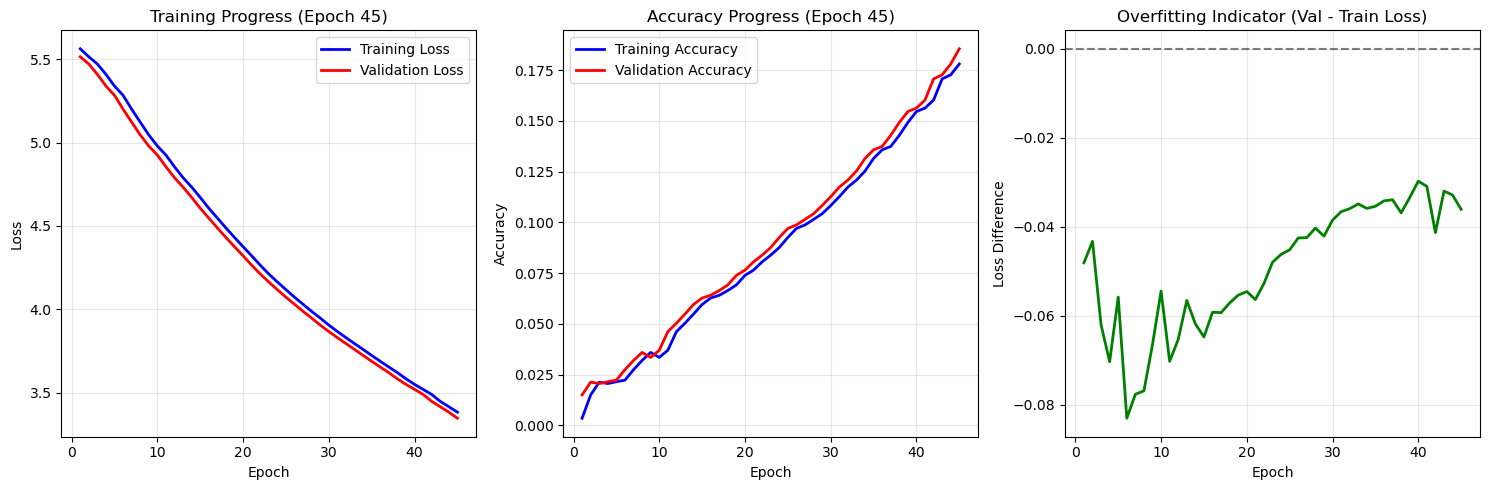


Epoch 46/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 3.3148
Train Loss: 3.3467 | Train Acc: 0.186
Val Loss: 3.3148 | Val Acc: 0.188 🔥
LR: 0.001000

Epoch 47/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 3.2117
Train Loss: 3.2475 | Train Acc: 0.201
Val Loss: 3.2117 | Val Acc: 0.209 🔥
LR: 0.001000

Epoch 50/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 3.1783
Train Loss: 3.2117 | Train Acc: 0.209
Val Loss: 3.1783 | Val Acc: 0.216 🔥
LR: 0.001000


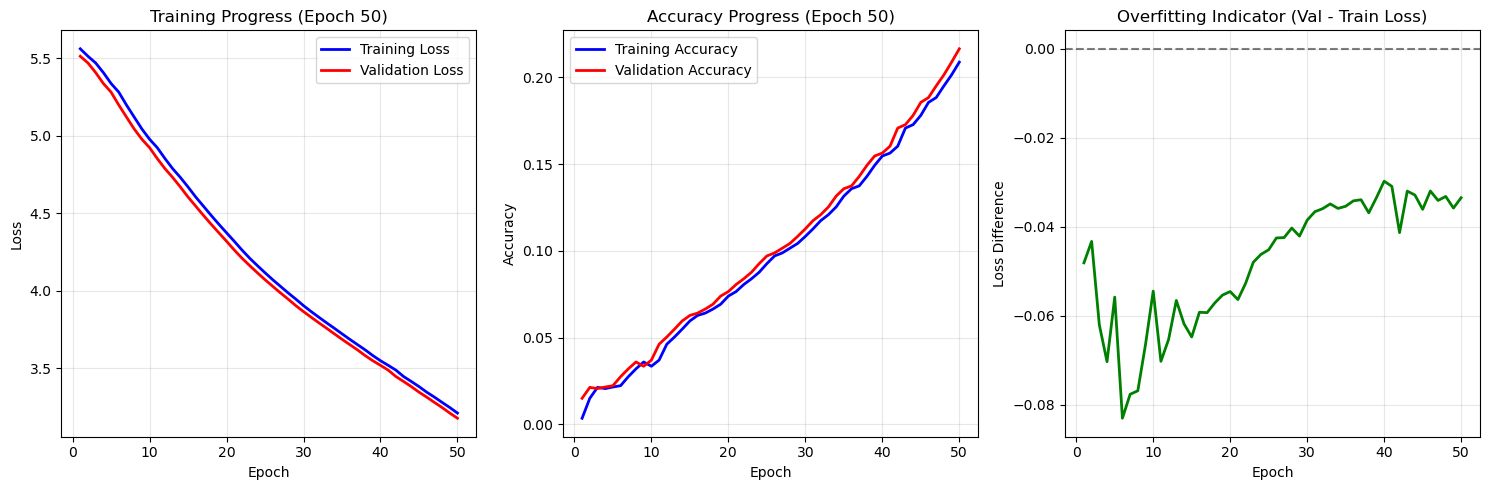


Epoch 51/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 3.1417
Train Loss: 3.1783 | Train Acc: 0.216
Val Loss: 3.1417 | Val Acc: 0.223 🔥
LR: 0.001000

Epoch 52/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 3.0446
Train Loss: 3.0706 | Train Acc: 0.239
Val Loss: 3.0446 | Val Acc: 0.241 🔥
LR: 0.001000

Epoch 55/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 3.0051
Train Loss: 3.0446 | Train Acc: 0.241
Val Loss: 3.0051 | Val Acc: 0.254 🔥
LR: 0.001000


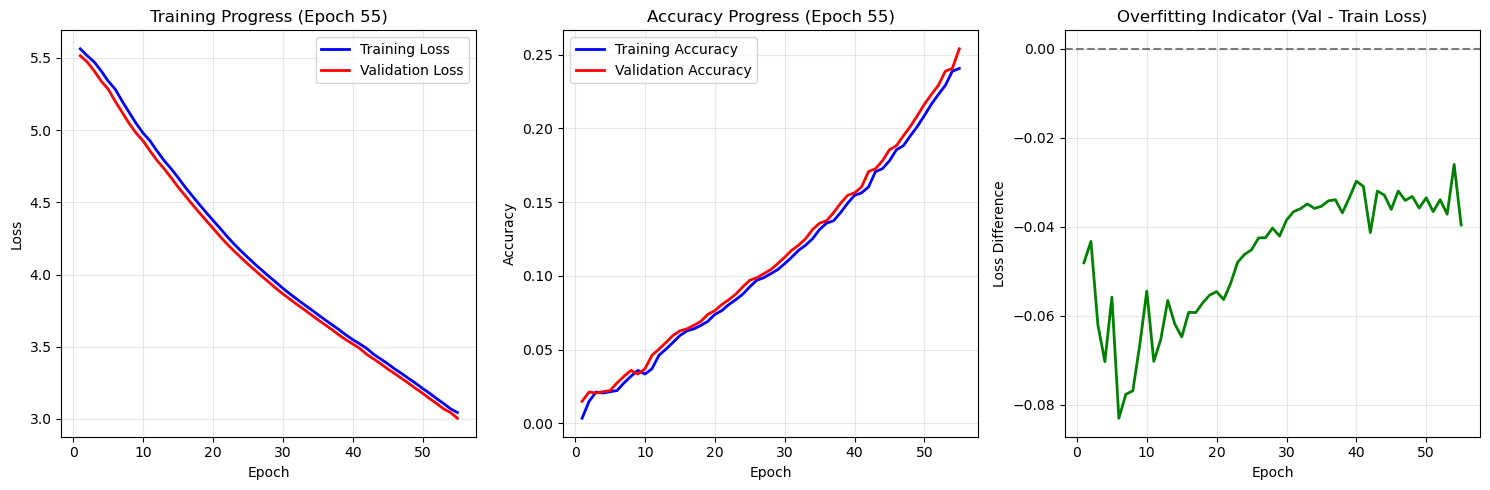


Epoch 56/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 2.9767
Train Loss: 3.0051 | Train Acc: 0.254
Val Loss: 2.9767 | Val Acc: 0.257 🔥
LR: 0.001000

Epoch 57/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 2.8560
Train Loss: 2.9112 | Train Acc: 0.266
Val Loss: 2.8560 | Val Acc: 0.283 🔥
LR: 0.001000

Epoch 60/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 2.8399
Train Loss: 2.8560 | Train Acc: 0.283
Val Loss: 2.8399 | Val Acc: 0.282 🔥
LR: 0.001000


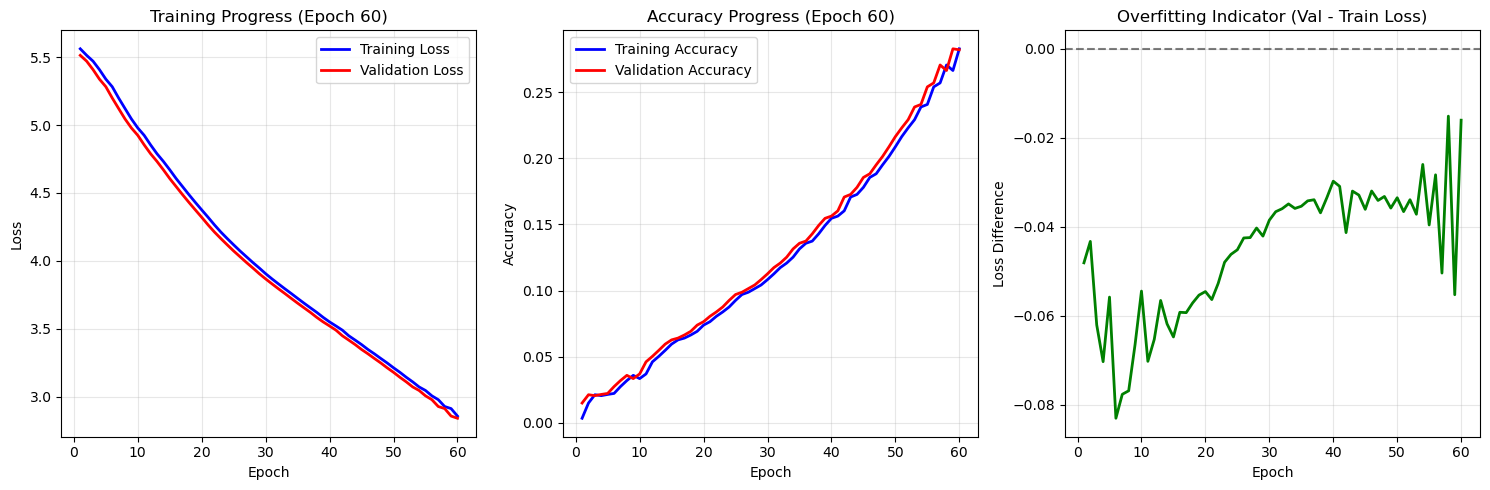


Epoch 61/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 2.7884
Train Loss: 2.8399 | Train Acc: 0.282
Val Loss: 2.7884 | Val Acc: 0.296 🔥
LR: 0.001000

Epoch 62/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 2.6797
Train Loss: 2.7257 | Train Acc: 0.307
Val Loss: 2.6797 | Val Acc: 0.321 🔥
LR: 0.001000

Epoch 65/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 2.6531
Train Loss: 2.6797 | Train Acc: 0.321
Val Loss: 2.6531 | Val Acc: 0.330 🔥
LR: 0.001000


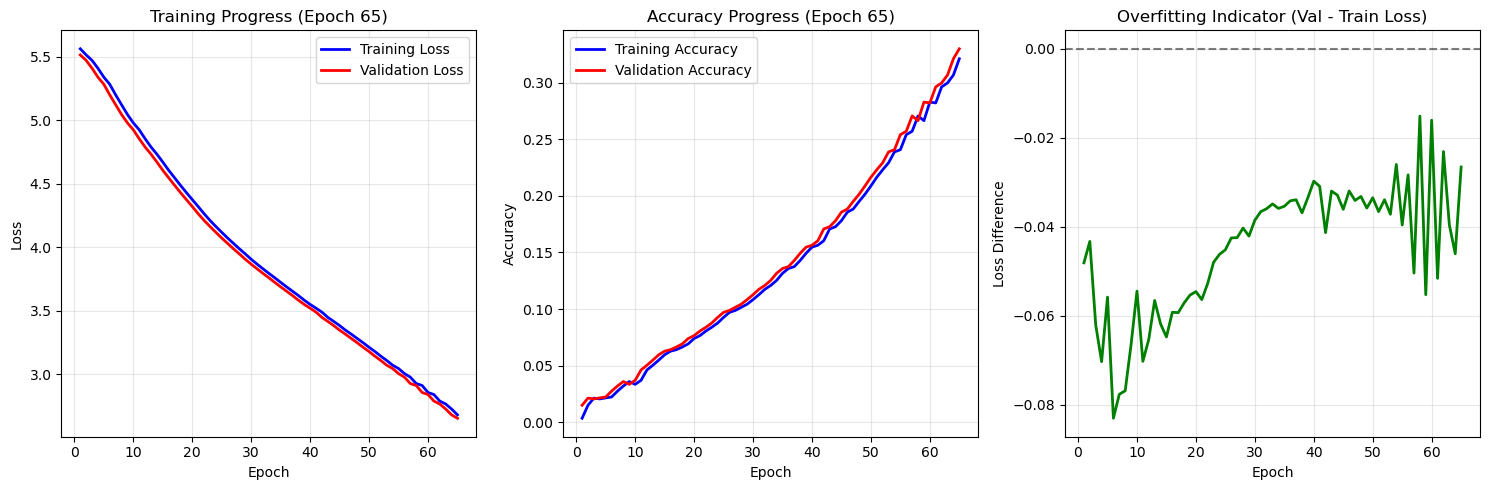


Epoch 66/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 2.6095
Train Loss: 2.6531 | Train Acc: 0.330
Val Loss: 2.6095 | Val Acc: 0.336 🔥
LR: 0.001000

Epoch 67/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 2.5016
Train Loss: 2.5362 | Train Acc: 0.356
Val Loss: 2.5016 | Val Acc: 0.367 🔥
LR: 0.001000

Epoch 70/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 2.4640
Train Loss: 2.5016 | Train Acc: 0.367
Val Loss: 2.4640 | Val Acc: 0.377 🔥
LR: 0.001000


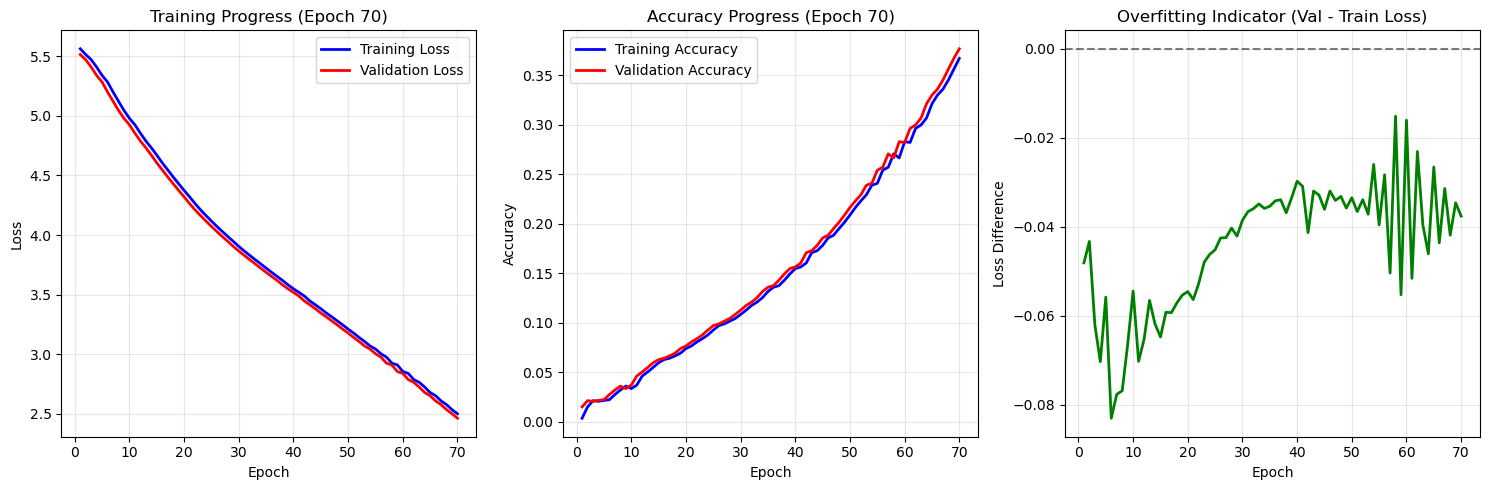


Epoch 71/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 2.4235
Train Loss: 2.4640 | Train Acc: 0.377
Val Loss: 2.4235 | Val Acc: 0.386 🔥
LR: 0.001000

Epoch 72/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 2.3246
Train Loss: 2.3509 | Train Acc: 0.410
Val Loss: 2.3246 | Val Acc: 0.413 🔥
LR: 0.001000

Epoch 75/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 2.2723
Train Loss: 2.3246 | Train Acc: 0.413
Val Loss: 2.2723 | Val Acc: 0.431 🔥
LR: 0.001000


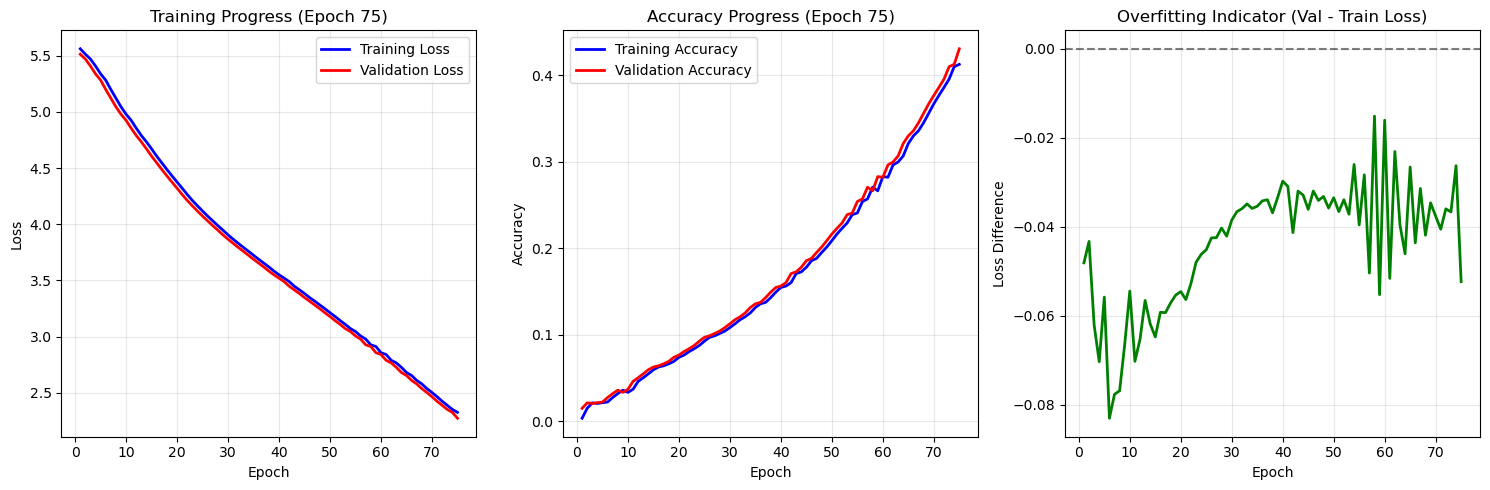


Epoch 76/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 2.2226
Train Loss: 2.2723 | Train Acc: 0.431
Val Loss: 2.2226 | Val Acc: 0.443 🔥
LR: 0.001000

Epoch 77/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 2.1126
Train Loss: 2.1515 | Train Acc: 0.462
Val Loss: 2.1126 | Val Acc: 0.470 🔥
LR: 0.001000

Epoch 80/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 2.0747
Train Loss: 2.1126 | Train Acc: 0.470
Val Loss: 2.0747 | Val Acc: 0.485 🔥
LR: 0.001000


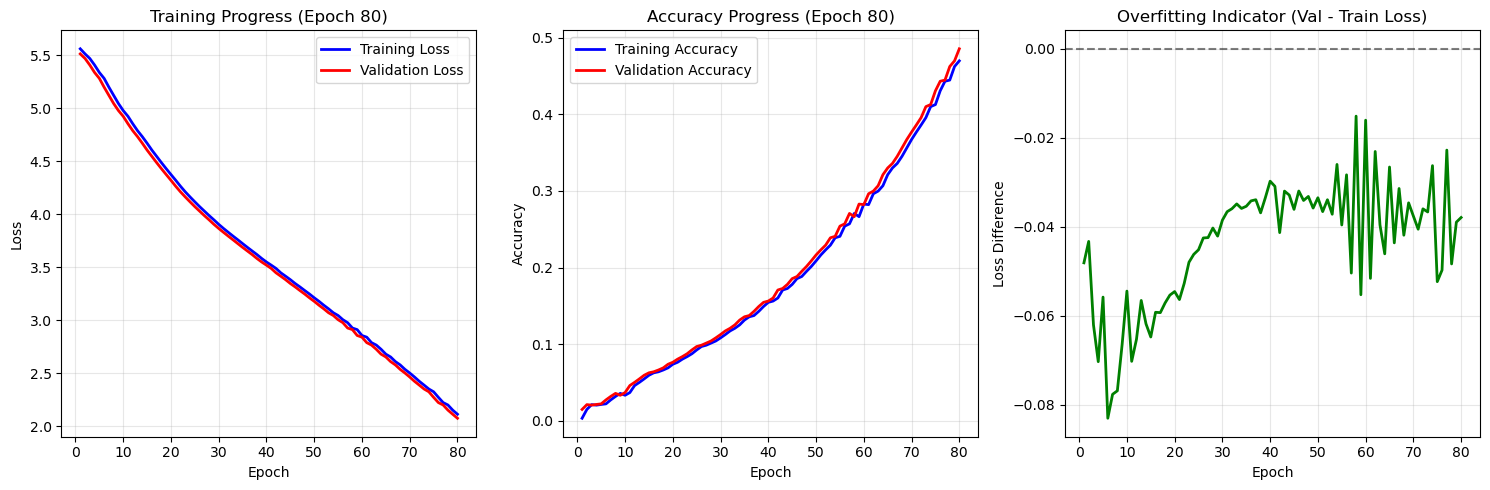


Epoch 81/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 2.0239
Train Loss: 2.0747 | Train Acc: 0.485
Val Loss: 2.0239 | Val Acc: 0.498 🔥
LR: 0.001000

Epoch 82/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 1.9000
Train Loss: 1.9452 | Train Acc: 0.517
Val Loss: 1.9000 | Val Acc: 0.537 🔥
LR: 0.001000

Epoch 85/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 1.8625
Train Loss: 1.9000 | Train Acc: 0.537
Val Loss: 1.8625 | Val Acc: 0.543 🔥
LR: 0.001000


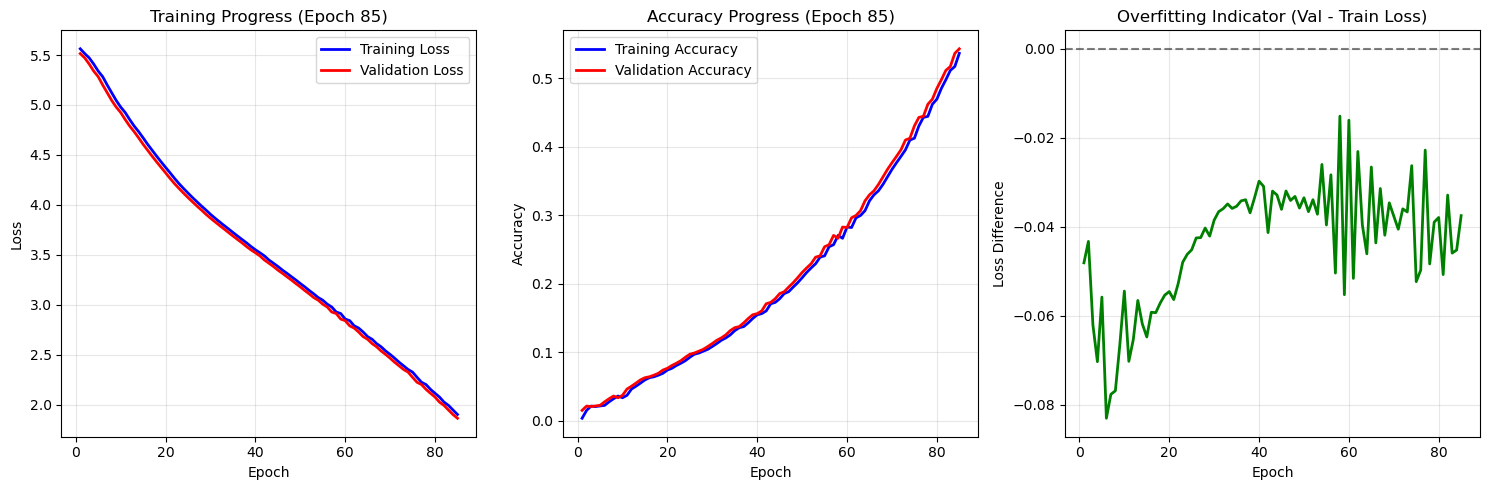


Epoch 86/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 1.8113
Train Loss: 1.8625 | Train Acc: 0.543
Val Loss: 1.8113 | Val Acc: 0.561 🔥
LR: 0.001000

Epoch 87/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 1.6849
Train Loss: 1.7220 | Train Acc: 0.587
Val Loss: 1.6849 | Val Acc: 0.598 🔥
LR: 0.001000

Epoch 90/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 1.6408
Train Loss: 1.6849 | Train Acc: 0.598
Val Loss: 1.6408 | Val Acc: 0.612 🔥
LR: 0.001000


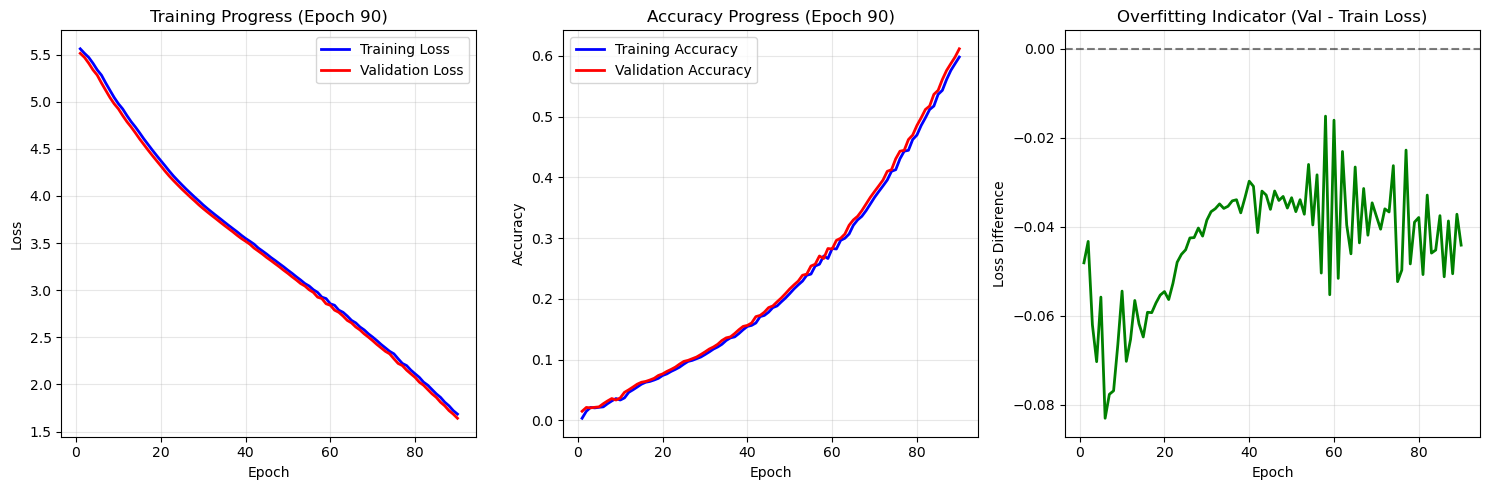


Epoch 91/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 1.5887
Train Loss: 1.6408 | Train Acc: 0.612
Val Loss: 1.5887 | Val Acc: 0.629 🔥
LR: 0.001000

Epoch 92/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 1.4655
Train Loss: 1.5117 | Train Acc: 0.650
Val Loss: 1.4655 | Val Acc: 0.661 🔥
LR: 0.001000

Epoch 95/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 1.4290
Train Loss: 1.4655 | Train Acc: 0.661
Val Loss: 1.4290 | Val Acc: 0.671 🔥
LR: 0.001000


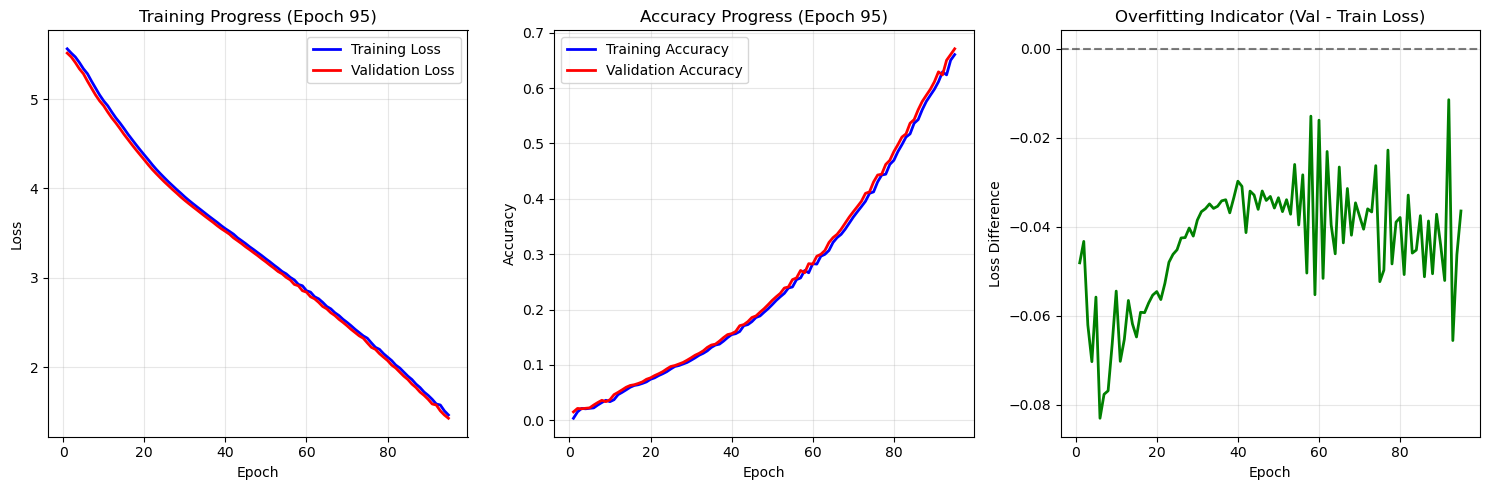


Epoch 96/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 1.3945
Train Loss: 1.4290 | Train Acc: 0.671
Val Loss: 1.3945 | Val Acc: 0.684 🔥
LR: 0.001000

Epoch 97/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 1.2694
Train Loss: 1.3126 | Train Acc: 0.711
Val Loss: 1.2694 | Val Acc: 0.722 🔥
LR: 0.001000

Epoch 100/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 1.2221
Train Loss: 1.2694 | Train Acc: 0.722
Val Loss: 1.2221 | Val Acc: 0.743 🔥
LR: 0.001000


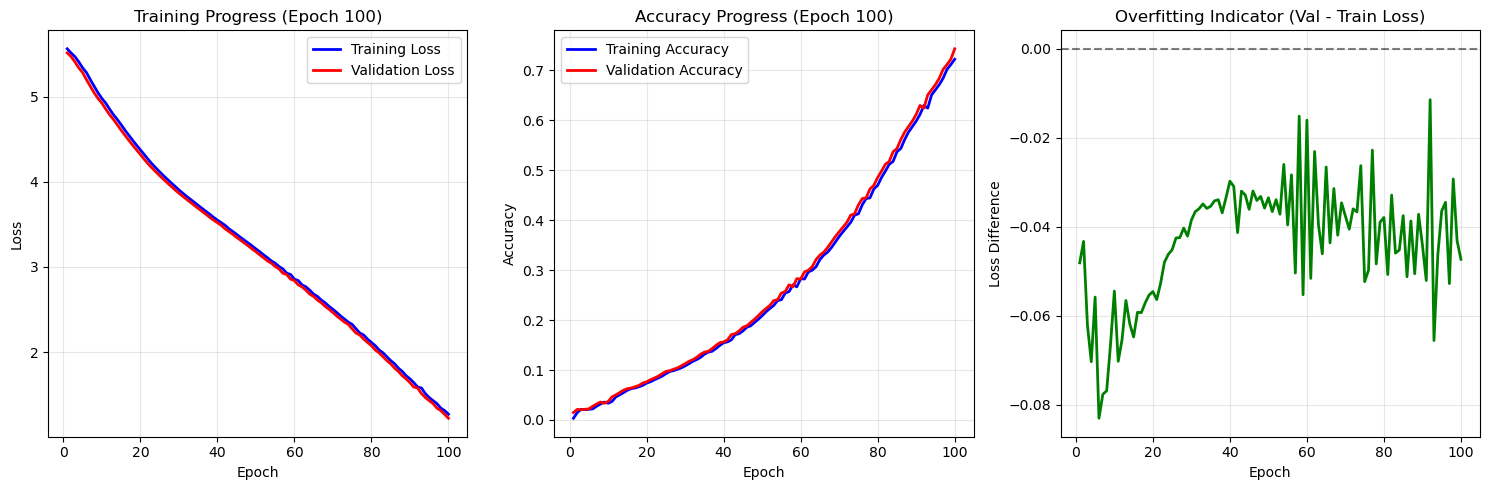


Epoch 101/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 1.1856
Train Loss: 1.2221 | Train Acc: 0.743
Val Loss: 1.1856 | Val Acc: 0.747 🔥
LR: 0.001000

Epoch 102/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 1.0814
Train Loss: 1.1139 | Train Acc: 0.775
Val Loss: 1.0814 | Val Acc: 0.781 🔥
LR: 0.001000

Epoch 105/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 1.0407
Train Loss: 1.0814 | Train Acc: 0.781
Val Loss: 1.0407 | Val Acc: 0.797 🔥
LR: 0.001000


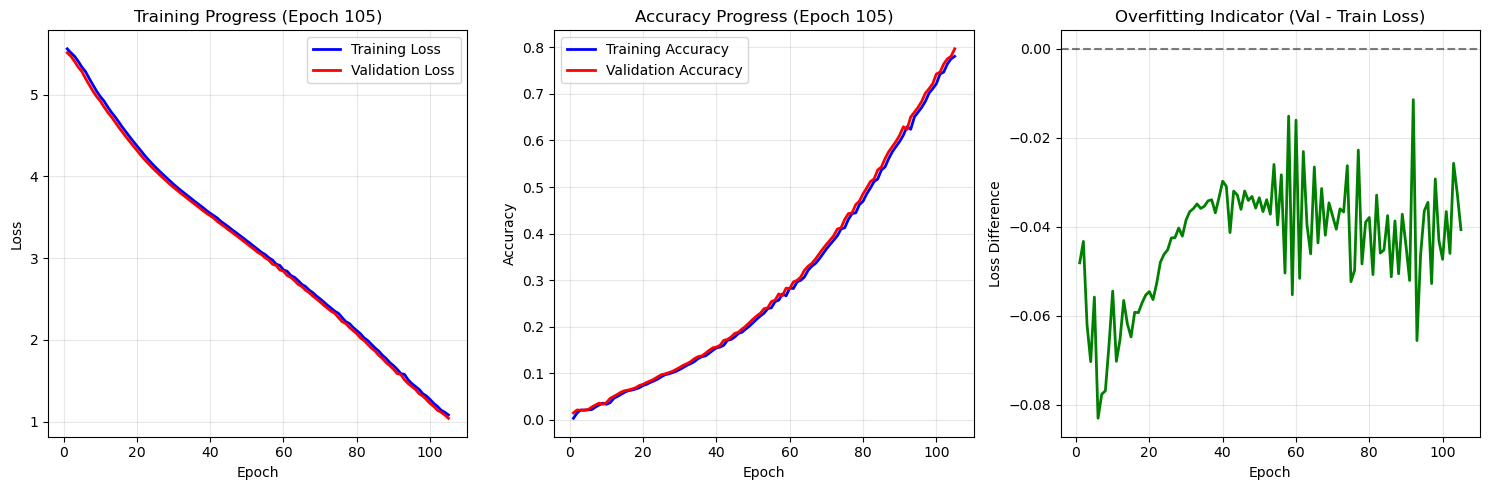


Epoch 106/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 0.9903
Train Loss: 1.0407 | Train Acc: 0.797
Val Loss: 0.9903 | Val Acc: 0.813 🔥
LR: 0.001000

Epoch 107/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 0.8984
Train Loss: 0.9203 | Train Acc: 0.834
Val Loss: 0.8984 | Val Acc: 0.835 🔥
LR: 0.001000

Epoch 110/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 0.8532
Train Loss: 0.8984 | Train Acc: 0.835
Val Loss: 0.8532 | Val Acc: 0.852 🔥
LR: 0.001000


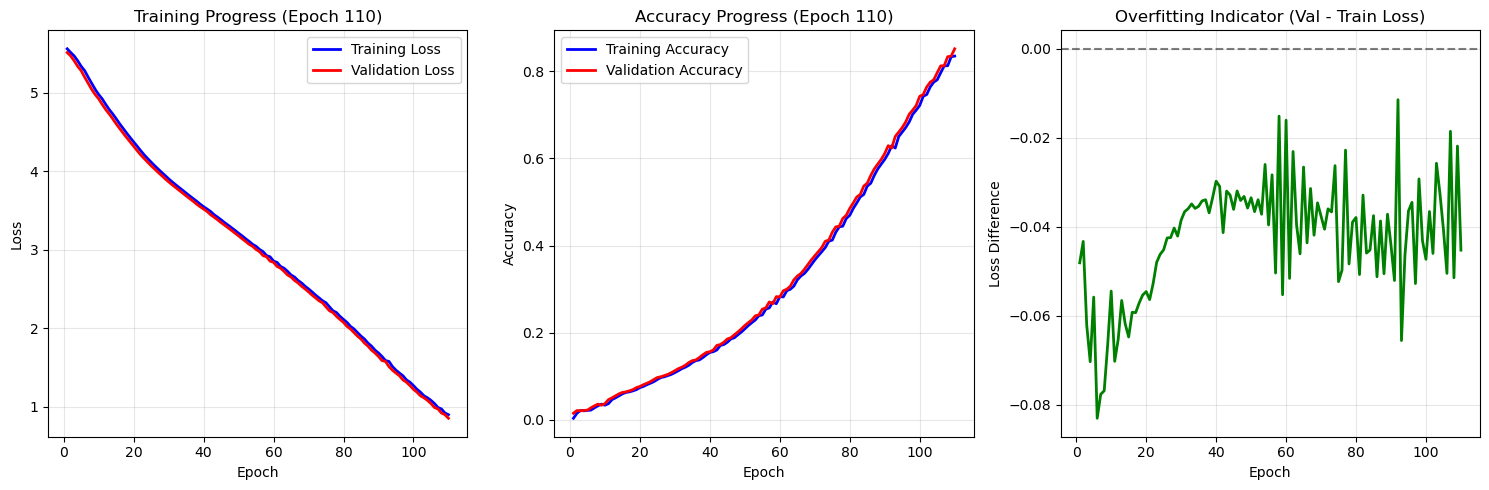


Epoch 111/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 0.8321
Train Loss: 0.8532 | Train Acc: 0.852
Val Loss: 0.8321 | Val Acc: 0.854 🔥
LR: 0.001000

Epoch 112/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 0.7221
Train Loss: 0.7598 | Train Acc: 0.880
Val Loss: 0.7221 | Val Acc: 0.890 🔥
LR: 0.001000

Epoch 115/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 0.6941
Train Loss: 0.7221 | Train Acc: 0.890
Val Loss: 0.6941 | Val Acc: 0.897 🔥
LR: 0.001000


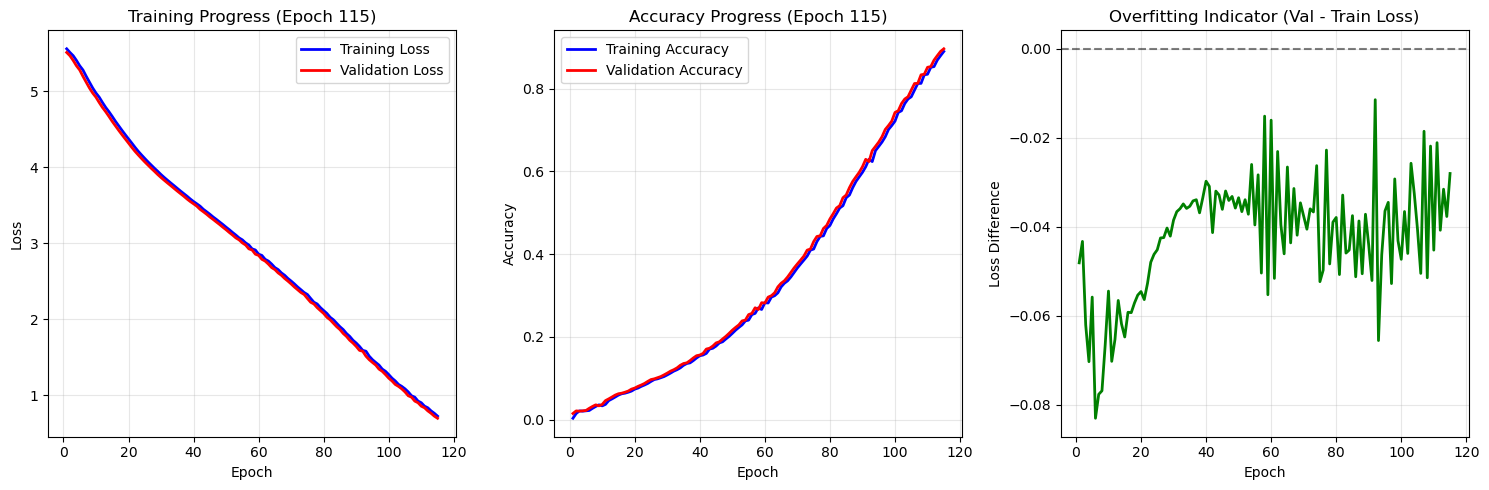


Epoch 116/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 0.6605
Train Loss: 0.6941 | Train Acc: 0.897
Val Loss: 0.6605 | Val Acc: 0.910 🔥
LR: 0.001000

Epoch 117/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 0.5790
Train Loss: 0.6080 | Train Acc: 0.922
Val Loss: 0.5790 | Val Acc: 0.929 🔥
LR: 0.001000

Epoch 120/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 0.5533
Train Loss: 0.5790 | Train Acc: 0.929
Val Loss: 0.5533 | Val Acc: 0.936 🔥
LR: 0.001000


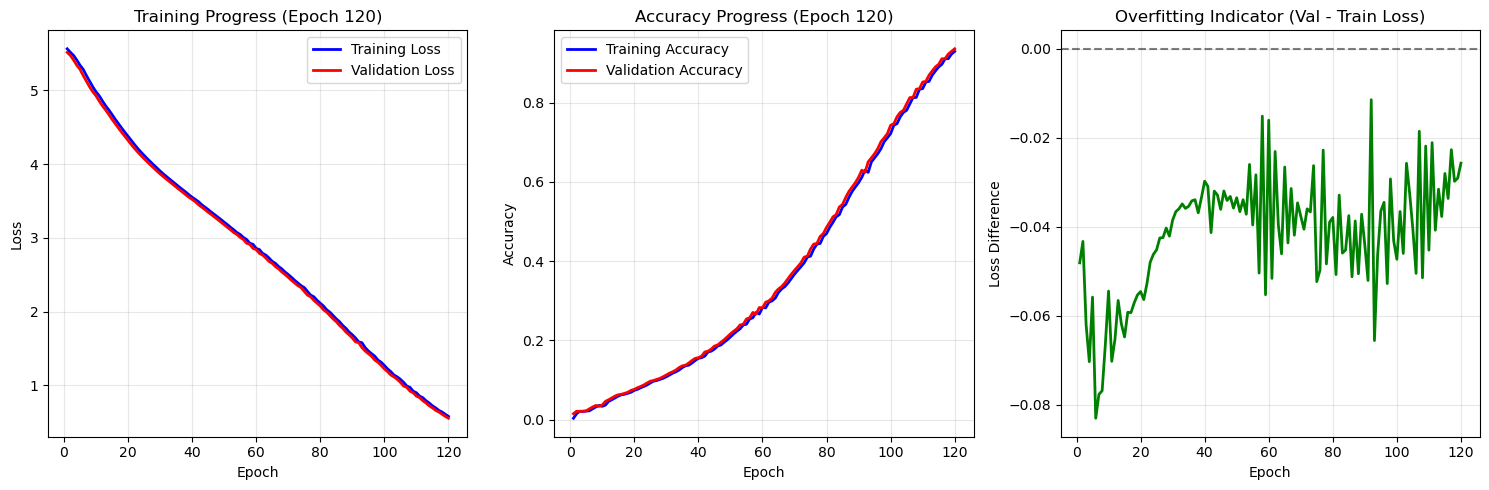


Epoch 121/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 0.5208
Train Loss: 0.5533 | Train Acc: 0.936
Val Loss: 0.5208 | Val Acc: 0.944 🔥
LR: 0.001000

Epoch 122/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 0.4565
Train Loss: 0.4670 | Train Acc: 0.956
Val Loss: 0.4565 | Val Acc: 0.959 🔥
LR: 0.001000

Epoch 125/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 0.4253
Train Loss: 0.4565 | Train Acc: 0.959
Val Loss: 0.4253 | Val Acc: 0.964 🔥
LR: 0.001000


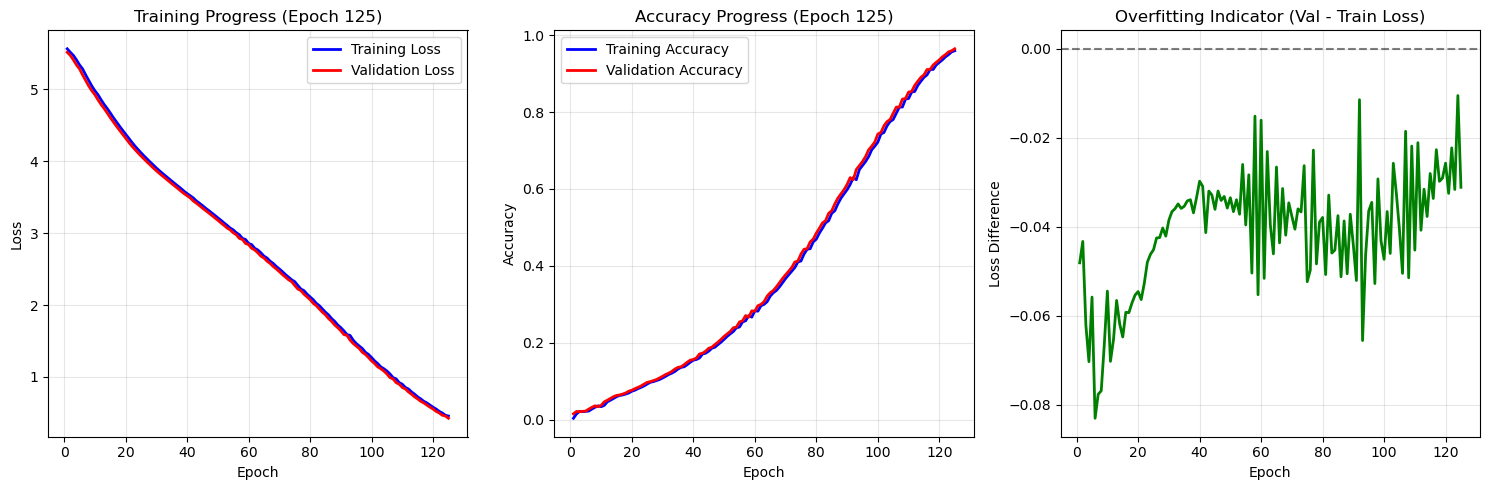


Epoch 126/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 0.4027
Train Loss: 0.4253 | Train Acc: 0.964
Val Loss: 0.4027 | Val Acc: 0.970 🔥
LR: 0.001000

Epoch 127/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 0.3402
Train Loss: 0.3606 | Train Acc: 0.975
Val Loss: 0.3402 | Val Acc: 0.980 🔥
LR: 0.001000

Epoch 130/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 0.3125
Train Loss: 0.3402 | Train Acc: 0.980
Val Loss: 0.3125 | Val Acc: 0.985 🔥
LR: 0.001000


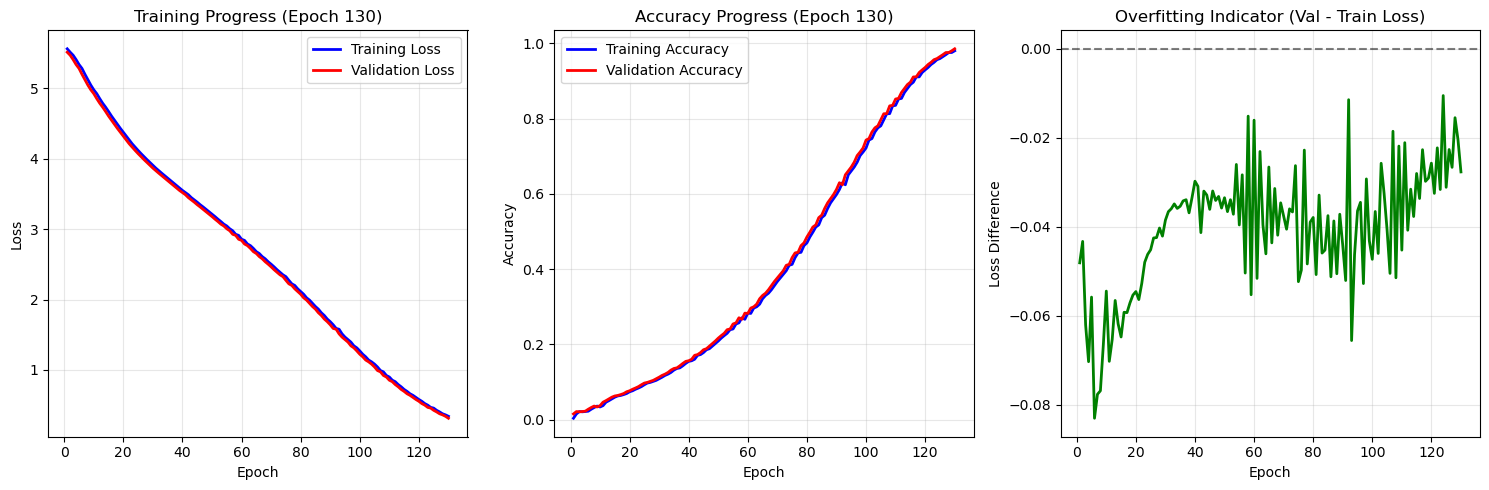


Epoch 131/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 0.3034
Train Loss: 0.3125 | Train Acc: 0.985
Val Loss: 0.3034 | Val Acc: 0.986 🔥
LR: 0.001000

Epoch 132/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 0.2439
Train Loss: 0.2631 | Train Acc: 0.991
Val Loss: 0.2439 | Val Acc: 0.993 🔥
LR: 0.001000

Epoch 135/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 0.2293
Train Loss: 0.2439 | Train Acc: 0.993
Val Loss: 0.2293 | Val Acc: 0.992 🔥
LR: 0.001000


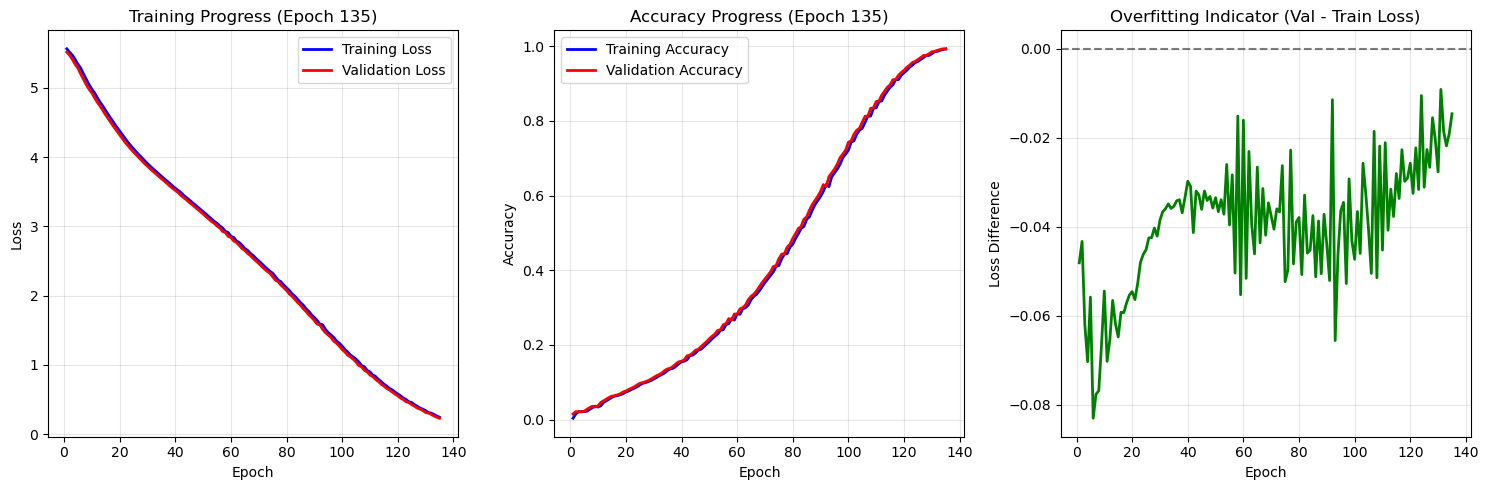


Epoch 136/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 0.2108
Train Loss: 0.2293 | Train Acc: 0.992
Val Loss: 0.2108 | Val Acc: 0.996 🔥
LR: 0.001000

Epoch 137/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 0.1742
Train Loss: 0.1886 | Train Acc: 0.998
Val Loss: 0.1742 | Val Acc: 0.998 🔥
LR: 0.001000

Epoch 140/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 0.1653
Train Loss: 0.1742 | Train Acc: 0.998
Val Loss: 0.1653 | Val Acc: 0.998 🔥
LR: 0.001000


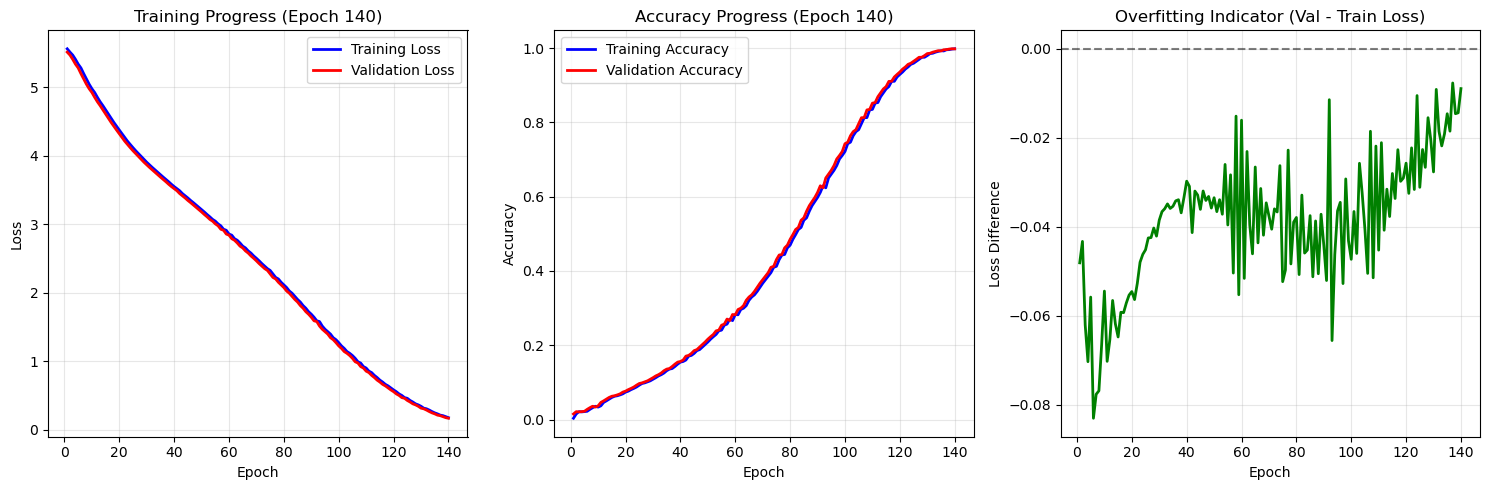


Epoch 141/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 0.1498
Train Loss: 0.1653 | Train Acc: 0.998
Val Loss: 0.1498 | Val Acc: 0.998 🔥
LR: 0.001000

Epoch 142/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 0.1188
Train Loss: 0.1303 | Train Acc: 1.000
Val Loss: 0.1188 | Val Acc: 1.000 🔥
LR: 0.001000

Epoch 145/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 0.1114
Train Loss: 0.1188 | Train Acc: 1.000
Val Loss: 0.1114 | Val Acc: 1.000 🔥
LR: 0.001000


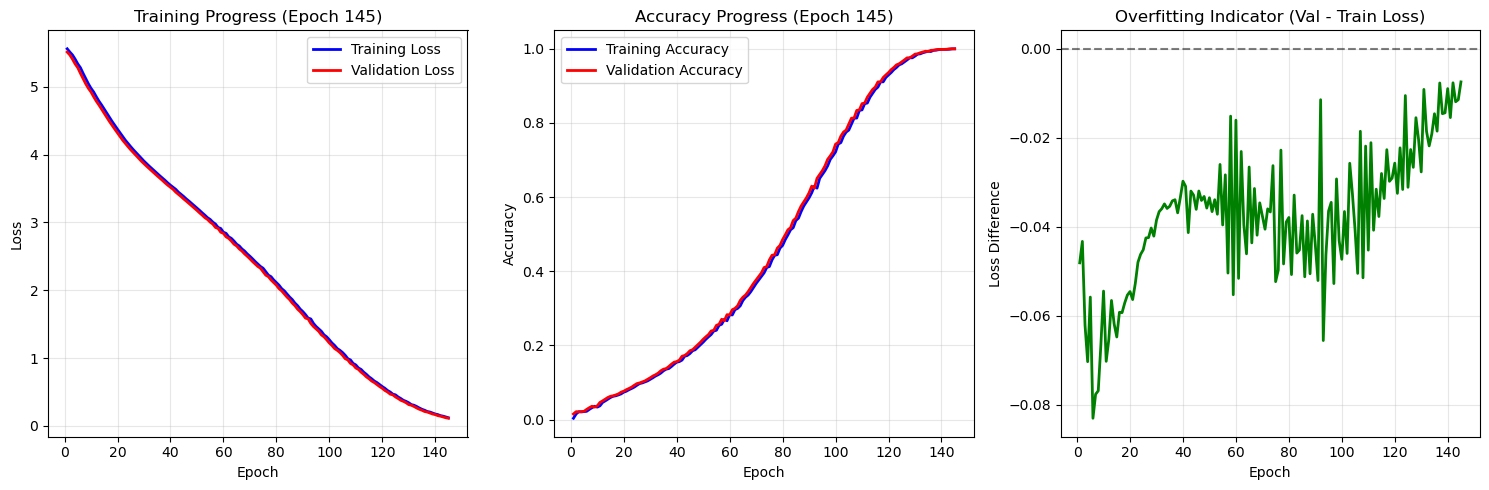


Epoch 146/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 0.1039
Train Loss: 0.1114 | Train Acc: 1.000
Val Loss: 0.1039 | Val Acc: 1.000 🔥
LR: 0.001000

Epoch 147/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 0.0833
Train Loss: 0.0894 | Train Acc: 1.000
Val Loss: 0.0833 | Val Acc: 1.000 🔥
LR: 0.001000

Epoch 150/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 0.0772
Train Loss: 0.0833 | Train Acc: 1.000
Val Loss: 0.0772 | Val Acc: 1.000 🔥
LR: 0.001000


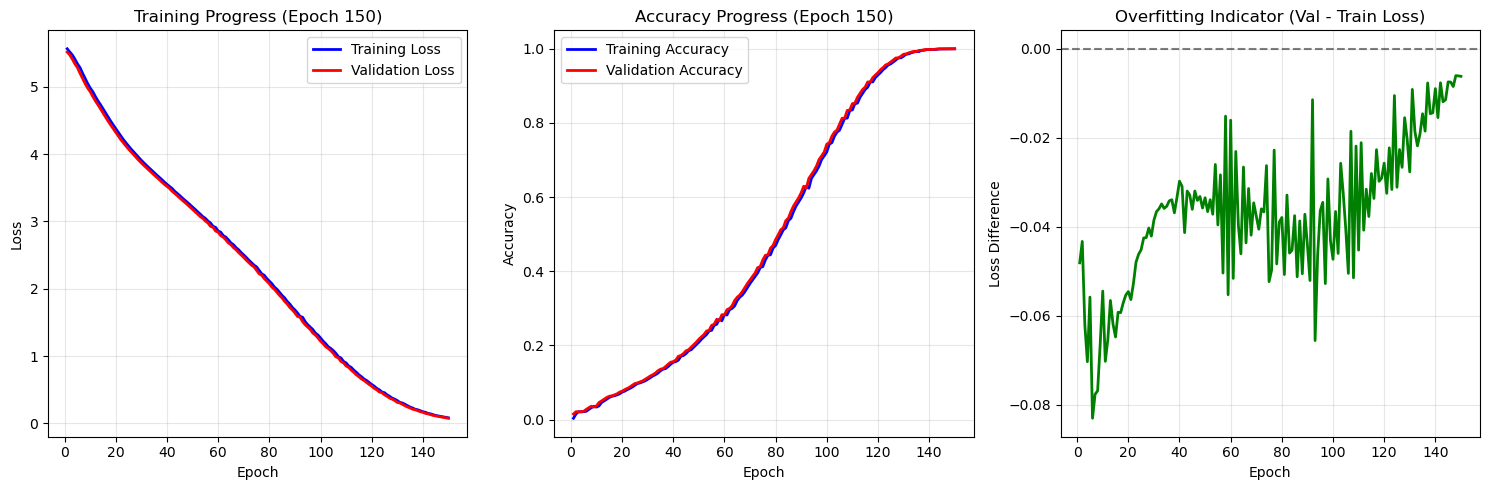


Epoch 151/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 0.0726
Train Loss: 0.0772 | Train Acc: 1.000
Val Loss: 0.0726 | Val Acc: 1.000 🔥
LR: 0.001000

Epoch 152/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 0.0595
Train Loss: 0.0632 | Train Acc: 1.000
Val Loss: 0.0595 | Val Acc: 1.000 🔥
LR: 0.001000

Epoch 155/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 0.0555
Train Loss: 0.0595 | Train Acc: 1.000
Val Loss: 0.0555 | Val Acc: 1.000 🔥
LR: 0.001000


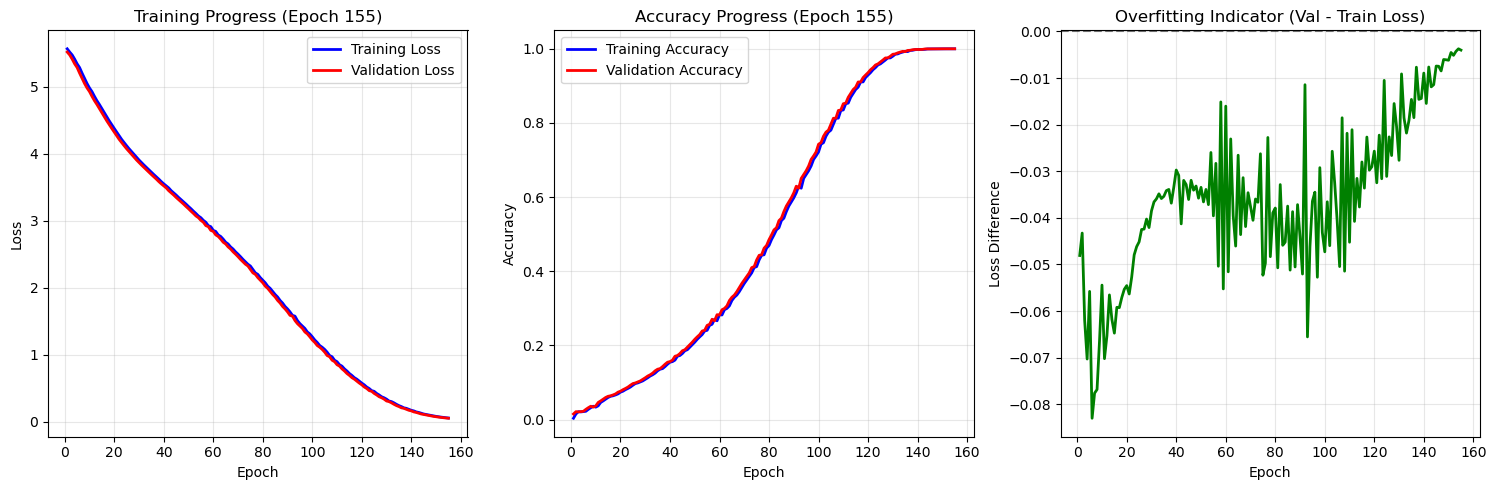


Epoch 156/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 0.0525
Train Loss: 0.0555 | Train Acc: 1.000
Val Loss: 0.0525 | Val Acc: 1.000 🔥
LR: 0.001000

Epoch 157/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 0.0439
Train Loss: 0.0465 | Train Acc: 1.000
Val Loss: 0.0439 | Val Acc: 1.000 🔥
LR: 0.001000

Epoch 160/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 0.0416
Train Loss: 0.0439 | Train Acc: 1.000
Val Loss: 0.0416 | Val Acc: 1.000 🔥
LR: 0.001000


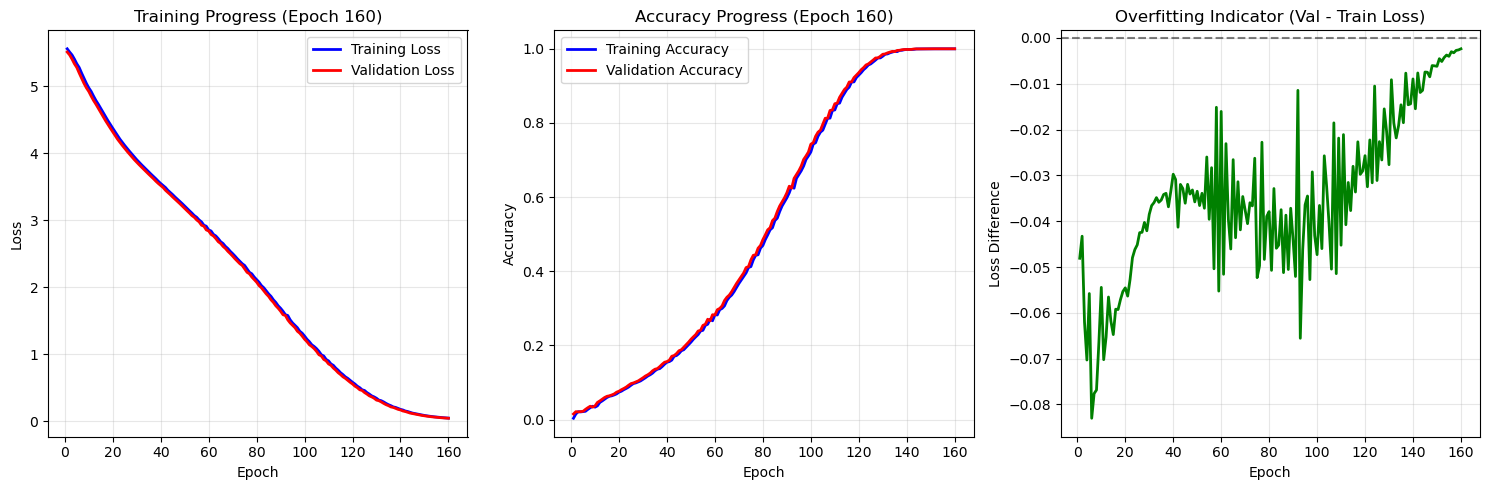


Epoch 161/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 0.0395
Train Loss: 0.0416 | Train Acc: 1.000
Val Loss: 0.0395 | Val Acc: 1.000 🔥
LR: 0.001000

Epoch 162/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 0.0339
Train Loss: 0.0356 | Train Acc: 1.000
Val Loss: 0.0339 | Val Acc: 1.000 🔥
LR: 0.001000

Epoch 165/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 0.0323
Train Loss: 0.0339 | Train Acc: 1.000
Val Loss: 0.0323 | Val Acc: 1.000 🔥
LR: 0.001000


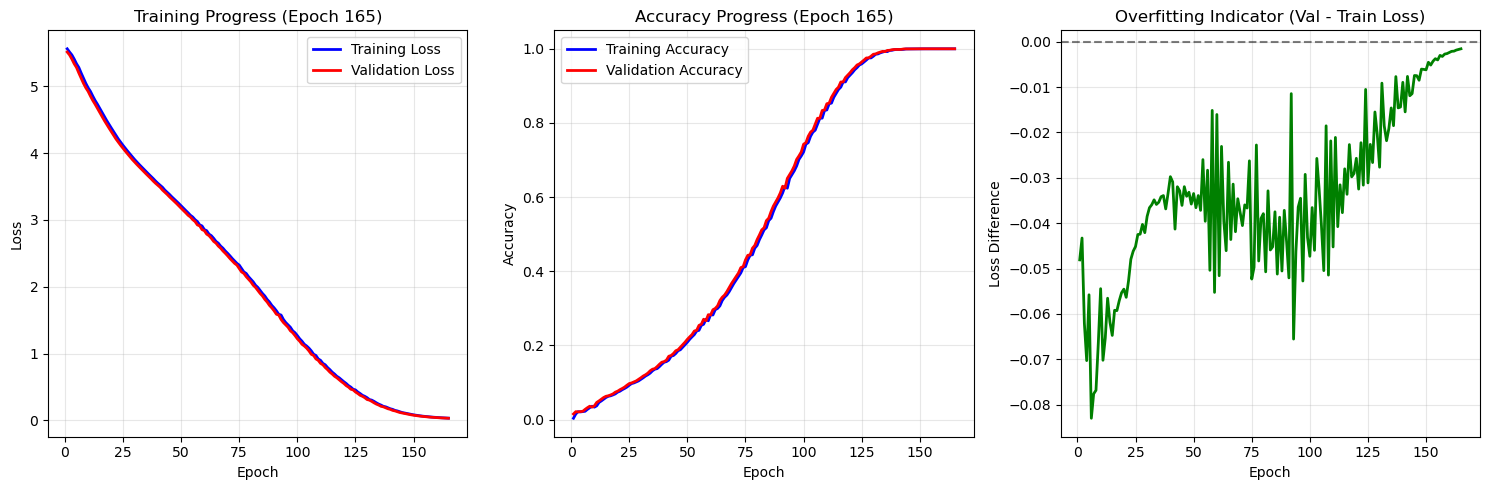


Epoch 166/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 0.0308
Train Loss: 0.0323 | Train Acc: 1.000
Val Loss: 0.0308 | Val Acc: 1.000 🔥
LR: 0.001000

Epoch 167/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 0.0271
Train Loss: 0.0283 | Train Acc: 1.000
Val Loss: 0.0271 | Val Acc: 1.000 🔥
LR: 0.001000

Epoch 170/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 0.0260
Train Loss: 0.0271 | Train Acc: 1.000
Val Loss: 0.0260 | Val Acc: 1.000 🔥
LR: 0.001000


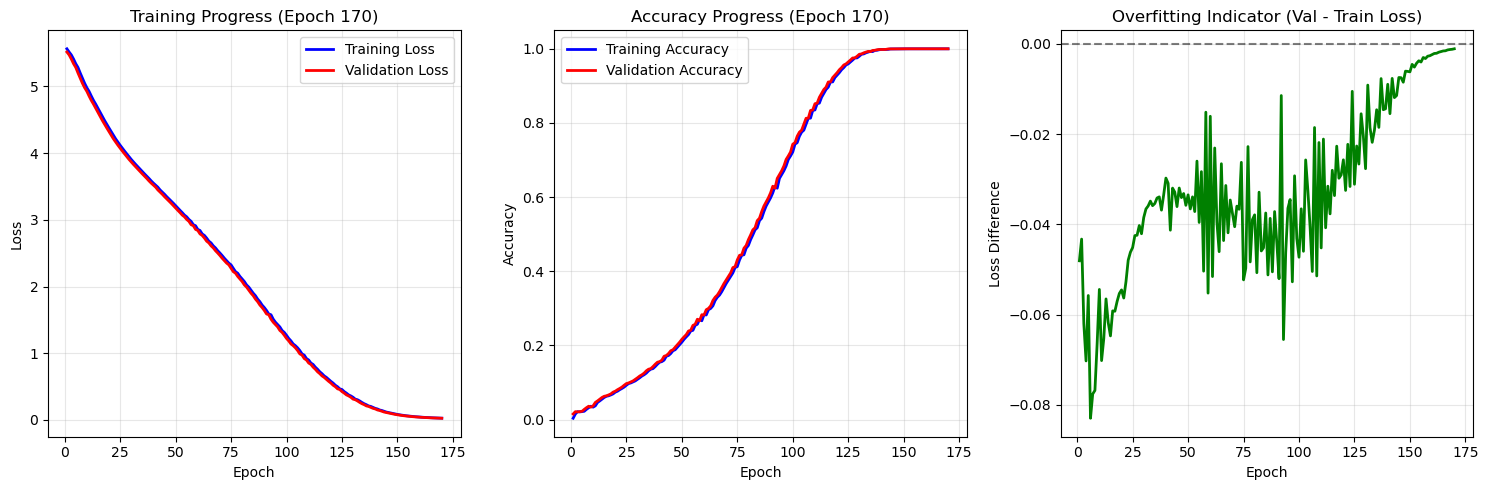


Epoch 171/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 0.0250
Train Loss: 0.0260 | Train Acc: 1.000
Val Loss: 0.0250 | Val Acc: 1.000 🔥
LR: 0.001000

Epoch 172/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 0.0223
Train Loss: 0.0232 | Train Acc: 1.000
Val Loss: 0.0223 | Val Acc: 1.000 🔥
LR: 0.001000

Epoch 175/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 0.0216
Train Loss: 0.0223 | Train Acc: 1.000
Val Loss: 0.0216 | Val Acc: 1.000 🔥
LR: 0.001000


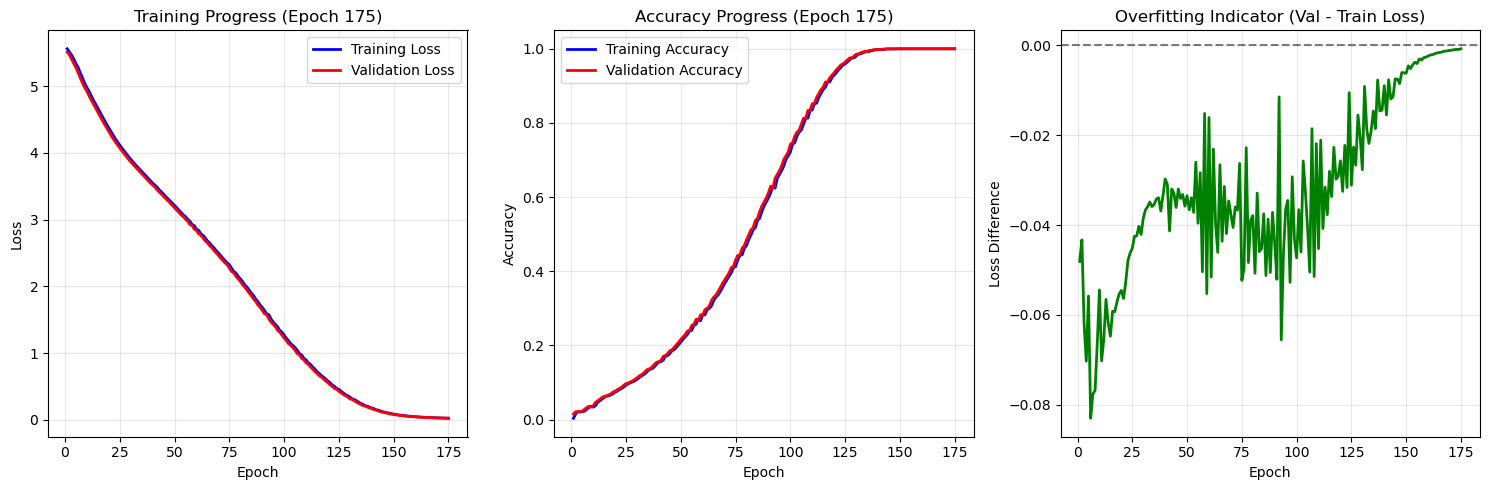


Epoch 176/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 0.0209
Train Loss: 0.0216 | Train Acc: 1.000
Val Loss: 0.0209 | Val Acc: 1.000 🔥
LR: 0.001000

Epoch 177/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 0.0189
Train Loss: 0.0195 | Train Acc: 1.000
Val Loss: 0.0189 | Val Acc: 1.000 🔥
LR: 0.001000

Epoch 180/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 0.0184
Train Loss: 0.0189 | Train Acc: 1.000
Val Loss: 0.0184 | Val Acc: 1.000 🔥
LR: 0.001000


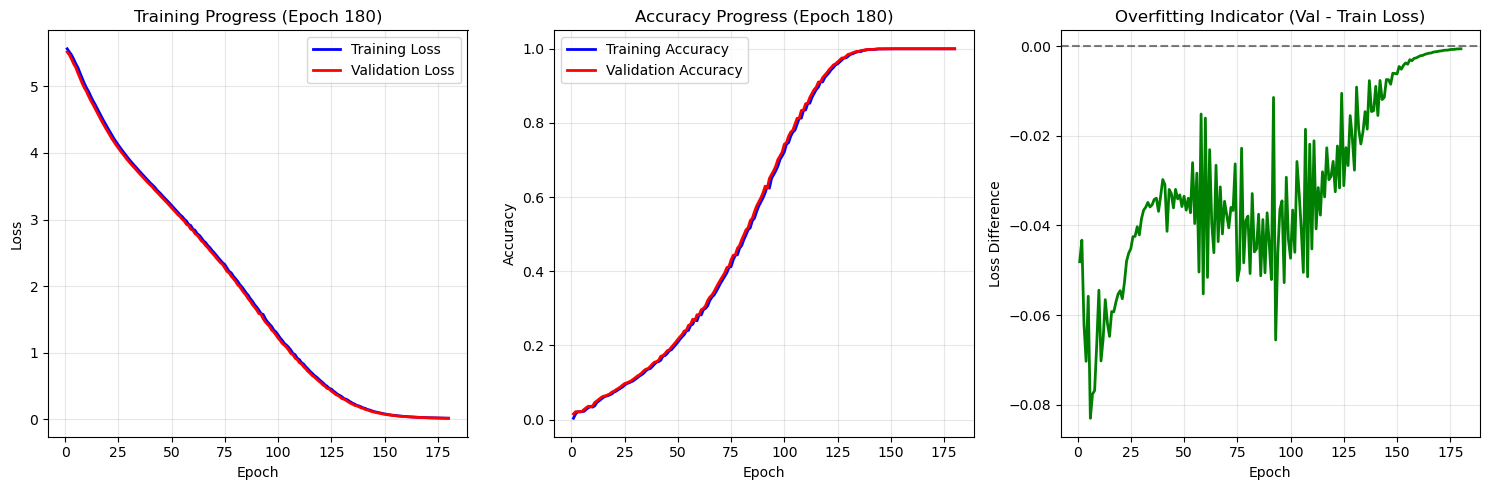


Epoch 181/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 0.0178
Train Loss: 0.0184 | Train Acc: 1.000
Val Loss: 0.0178 | Val Acc: 1.000 🔥
LR: 0.001000

Epoch 182/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 0.0164
Train Loss: 0.0168 | Train Acc: 1.000
Val Loss: 0.0164 | Val Acc: 1.000 🔥
LR: 0.001000

Epoch 185/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 0.0160
Train Loss: 0.0164 | Train Acc: 1.000
Val Loss: 0.0160 | Val Acc: 1.000 🔥
LR: 0.001000


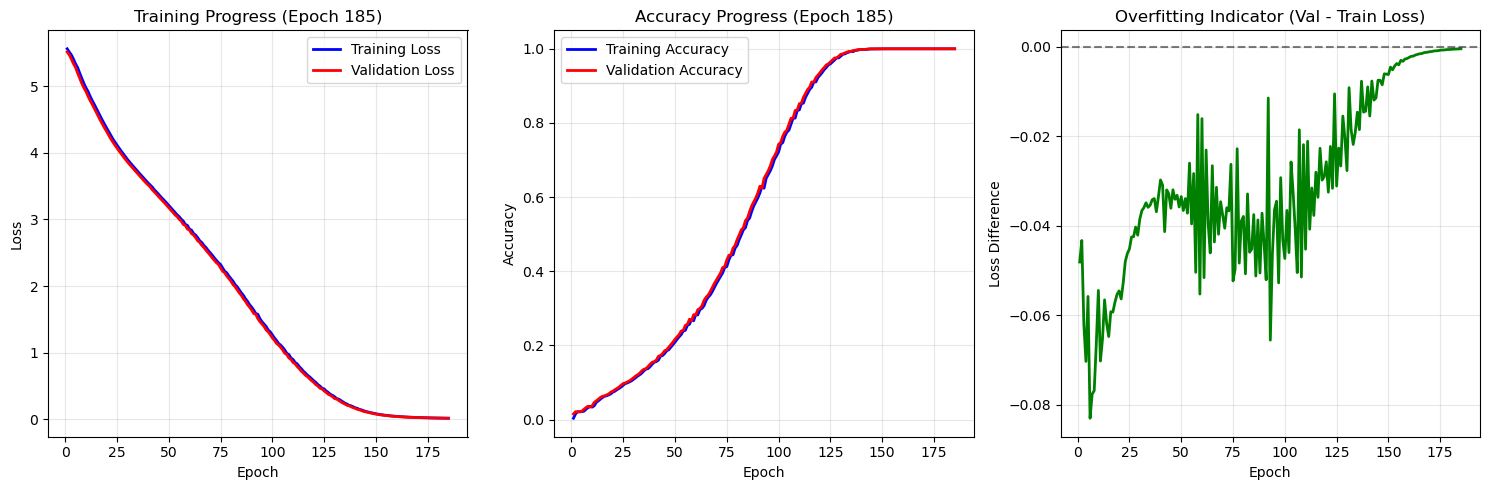


Epoch 186/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 0.0155
Train Loss: 0.0160 | Train Acc: 1.000
Val Loss: 0.0155 | Val Acc: 1.000 🔥
LR: 0.001000

Epoch 187/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 0.0144
Train Loss: 0.0148 | Train Acc: 1.000
Val Loss: 0.0144 | Val Acc: 1.000 🔥
LR: 0.001000

Epoch 190/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 0.0141
Train Loss: 0.0144 | Train Acc: 1.000
Val Loss: 0.0141 | Val Acc: 1.000 🔥
LR: 0.001000


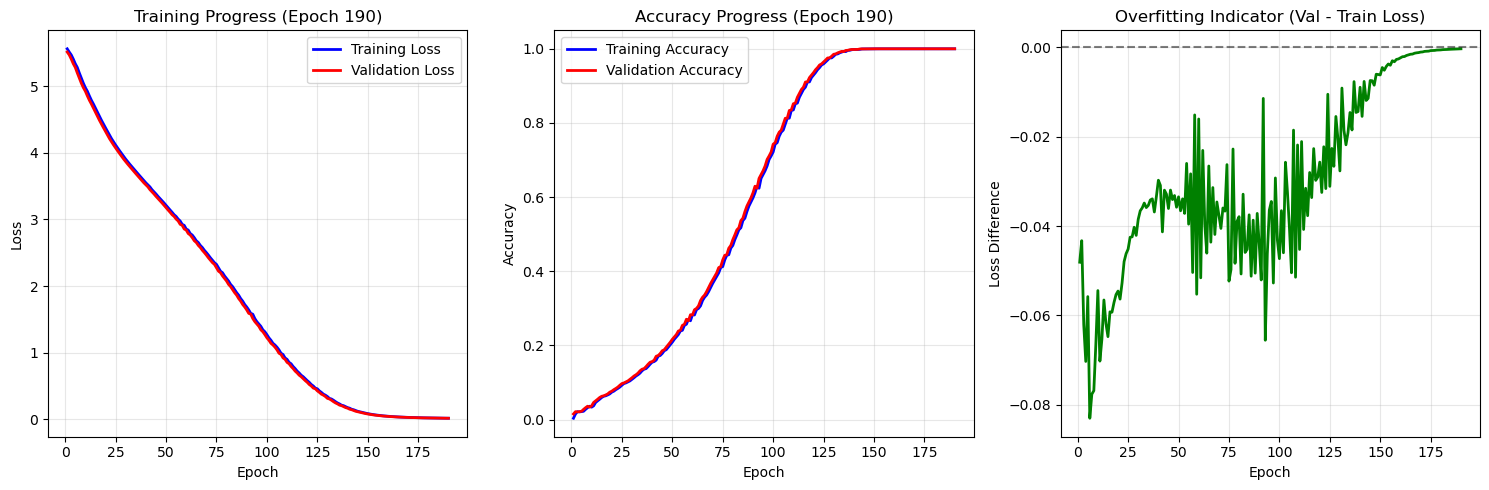


Epoch 191/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 0.0138
Train Loss: 0.0141 | Train Acc: 1.000
Val Loss: 0.0138 | Val Acc: 1.000 🔥
LR: 0.001000

Epoch 192/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 0.0129
Train Loss: 0.0132 | Train Acc: 1.000
Val Loss: 0.0129 | Val Acc: 1.000 🔥
LR: 0.001000

Epoch 195/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 0.0126
Train Loss: 0.0129 | Train Acc: 1.000
Val Loss: 0.0126 | Val Acc: 1.000 🔥
LR: 0.001000


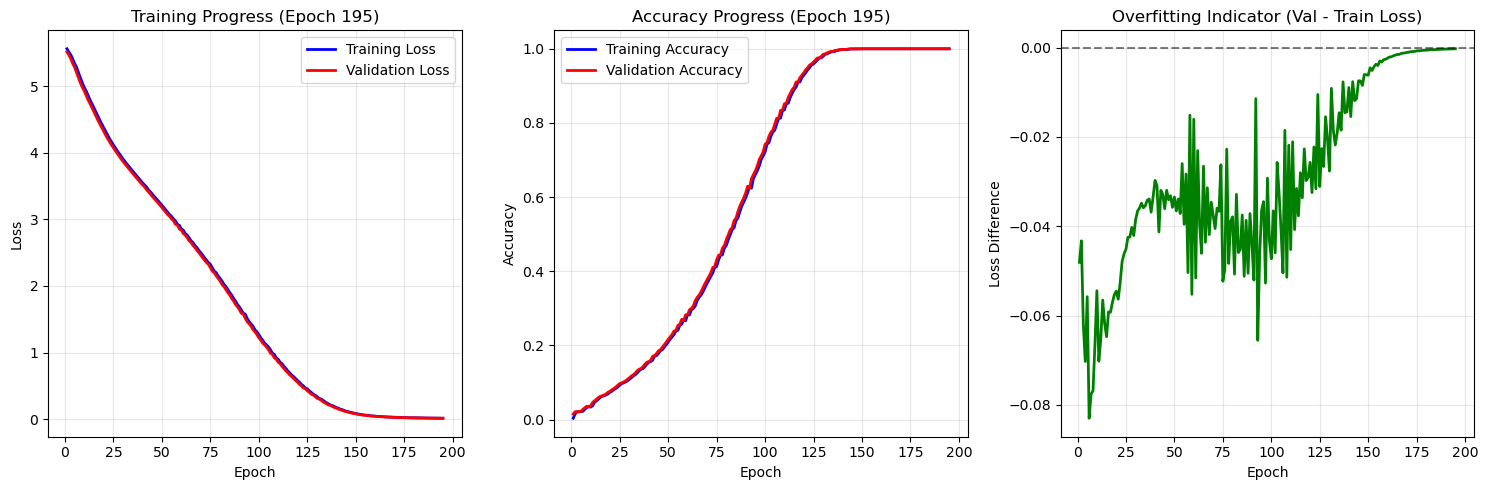


Epoch 196/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 0.0123
Train Loss: 0.0126 | Train Acc: 1.000
Val Loss: 0.0123 | Val Acc: 1.000 🔥
LR: 0.001000

Epoch 197/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 0.0116
Train Loss: 0.0118 | Train Acc: 1.000
Val Loss: 0.0116 | Val Acc: 1.000 🔥
LR: 0.001000

Epoch 200/200


Training:   0%|          | 0/1 [00:00<?, ?it/s]

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

💾 New best model saved! Val Loss: 0.0114
Train Loss: 0.0116 | Train Acc: 1.000
Val Loss: 0.0114 | Val Acc: 1.000 🔥
LR: 0.001000


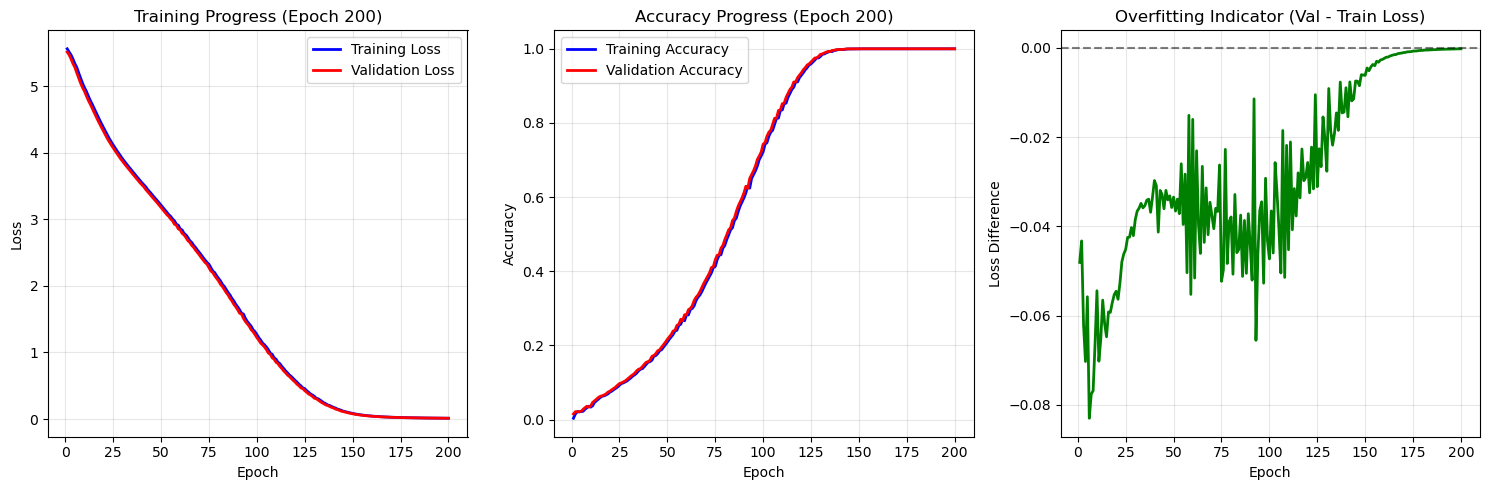


🎉 Training completed!
Best validation loss: 0.0114
Total epochs trained: 200
Checkpoints saved in: ./wavenet_checkpoints_fake


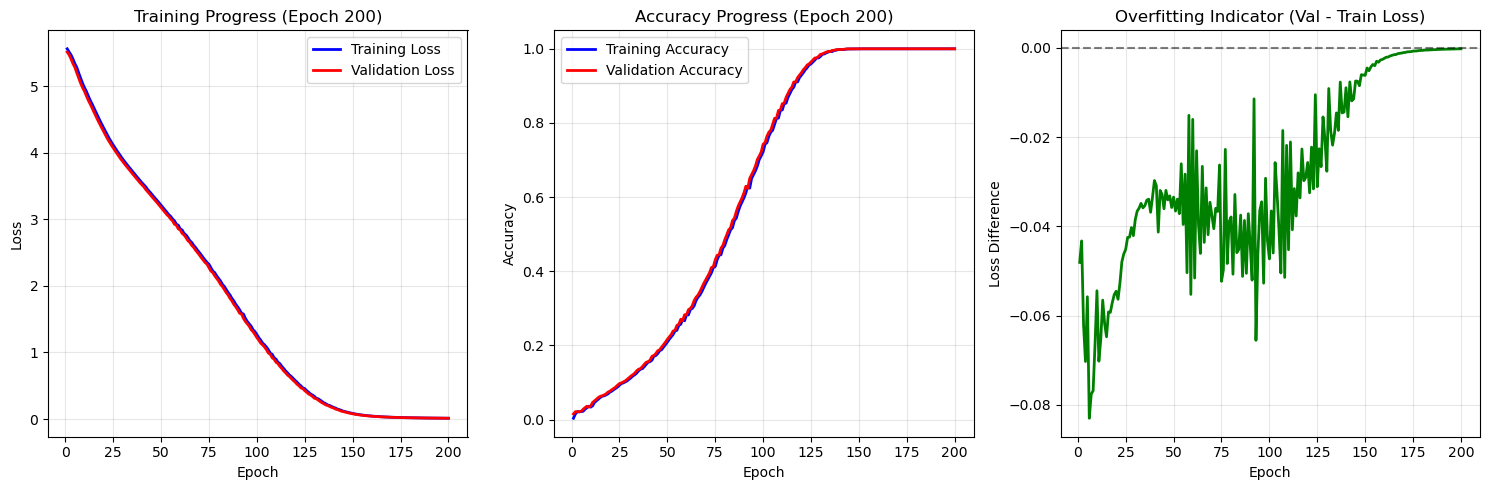

📋 Training summary saved to: ./wavenet_checkpoints_fake/training_summary.json


In [13]:
# Main training loop (resumed from checkpoint)
print(f"\n{'='*60}")
print(f"🚀 {'Resuming' if start_epoch > 0 else 'Starting'} WaveNet Training")
print(f"📊 Epochs: {start_epoch+1} → {num_epochs}")
print(f"💾 Checkpoints: {checkpoint_dir}")
print(f"{'='*60}")

for epoch in range(start_epoch, num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    
    # Training
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, device)
    
    # Validation
    val_loss, val_acc = validate_epoch(model, test_loader, device)
    
    # Update scheduler
    scheduler.step(val_loss)
    
    # Save metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)
    
    # Check for best model
    is_best = val_loss < best_val_loss
    if is_best:
        best_val_loss = val_loss
    
    # Save checkpoint every epoch
    save_checkpoint(epoch, model, optimizer, scheduler, train_losses, val_losses, 
                   train_accuracies, val_accuracies, best_val_loss, is_best)
    
    # Print epoch summary
    improvement = "🔥" if is_best else ""
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.3f}")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.3f} {improvement}")
    print(f"LR: {optimizer.param_groups[0]['lr']:.6f}")
    
    # Plot every 5 epochs or if it's the first resumed epoch
    if (epoch + 1) % 5 == 0 or epoch == start_epoch:
        plot_training_progress(train_losses, val_losses, train_accuracies, val_accuracies, epoch, checkpoint_dir)

print(f"\n🎉 Training completed!")
print(f"Best validation loss: {best_val_loss:.4f}")
print(f"Total epochs trained: {len(train_losses)}")
print(f"Checkpoints saved in: {checkpoint_dir}")

# Final comprehensive plot
plot_training_progress(train_losses, val_losses, train_accuracies, val_accuracies, len(train_losses)-1, checkpoint_dir)

# Save final results
final_results = {
    'total_epochs': len(train_losses),
    'best_val_loss': best_val_loss,
    'final_train_loss': train_losses[-1] if train_losses else None,
    'final_val_loss': val_losses[-1] if val_losses else None,
    'final_train_acc': train_accuracies[-1] if train_accuracies else None,
    'final_val_acc': val_accuracies[-1] if val_accuracies else None
}

import json
with open(os.path.join(checkpoint_dir, 'training_summary.json'), 'w') as f:
    json.dump(final_results, f, indent=2)

print(f"📋 Training summary saved to: {os.path.join(checkpoint_dir, 'training_summary.json')}")

In [14]:
import torch
import torch.nn.functional as F
from math import prod

# --- helper: compute receptive field for kernel=2, doubling dilations ---
def compute_receptive_field(n_blocks: int, n_layers: int, kernel_size: int = 2):
    # RF = 1 + B * (2^L - 1)  (for k=2)
    if kernel_size != 2:
        # general: RF = 1 + B * sum_{i=0..L-1} (k-1)*2^i
        return 1 + n_blocks * ((kernel_size - 1) * (2**n_layers - 1))
    return 1 + n_blocks * (2**n_layers - 1)

@torch.no_grad()
def generate_continuation(
    model,
    seed_tokens: torch.LongTensor,   # [B, T_seed], class IDs in [0..255]
    n_steps: int,                    # how many new samples to generate
    temperature: float = 1.0,
    top_k: int | None = None,
    device: str | torch.device = "cuda",
    rf_override: int | None = None,  # optionally pass model RF
):
    model.eval()
    seq = seed_tokens.to(device)  # [B, T_seed]
    B = seq.size(0)
    assert B == 1, "start with batch size 1 for autoregressive generation"

    # try to infer RF from model config if not provided
    if rf_override is not None:
        rf = rf_override
    else:
        # if you kept those in the model; otherwise, set a safe context like 4096
        n_blocks = getattr(model, "n_blocks", 3)
        n_layers = getattr(model, "n_layers", 10)
        ksize    = getattr(model, "K", 2)
        rf = compute_receptive_field(n_blocks, n_layers, ksize)

    for _ in tqdm(range(n_steps), desc='Generating'):
        # crop to receptive field context to save compute
        ctx = seq[:, -rf:] if seq.size(1) > rf else seq

        logits = model(ctx)          # [1, T_ctx, 256]
        logits = logits[:, -1, :]    # [1, 256] last step

        # temperature / top-k sampling (avoid argmax for better naturalness)
        logits = logits / max(temperature, 1e-6)
        if top_k is not None and top_k > 0:
            topk_vals, topk_idx = torch.topk(logits, k=top_k, dim=-1)
            probs = torch.zeros_like(logits).scatter(-1, topk_idx, F.softmax(topk_vals, dim=-1))
        else:
            probs = F.softmax(logits, dim=-1)

        next_tok = torch.multinomial(probs, num_samples=1)  # [1,1] Long
        seq = torch.cat([seq, next_tok], dim=1)             # append token

    return seq  # [1, T_seed + n_steps] (tokens)


In [ ]:
# Get one batch from test_loader; your collate_fn returns (x, y)
x_batch, _ = next(iter(test_loader))      # x: [B, T-1] tokens (Long)
x_batch = x_batch.to(device)

# Take the first item as seed; use 2s if you want, but they’re tokens already
seed = x_batch[:1, : 16000*2 - 1]         # [1, seed_len]; ensure <= available length

# Generate 2 more seconds (tokens are 1 sample each at 16kHz)
n_new = 16000 * 2

tokens_full = generate_continuation(
    model,
    seed_tokens=seed,
    n_steps=n_new,
    temperature=0.9,      # tweak 0.7–1.2
    top_k=100,            # optional; try None or 50–200
    device=device,
)

# μ-law decode to waveform in [-1,1]
mu = MuLawEncoding(mu=config['mu'])
audio_full = mu.mu_law_decode(tokens_full[0].cpu())   # [T_full] float in [-1,1]

# If you want to hear only the *generated continuation* (not the seed):
audio_cont = audio_full #[seed.size(1):]

# Listen/plot                                                                             
from IPython.display import Audio, display
import matplotlib.pyplot as plt
import numpy as np

print("Playing continuation...")
display(Audio(audio_cont.numpy(), rate=config['sr']))

plt.figure(figsize=(14,4))
plt.plot(audio_cont.numpy())
plt.title("Generated Audio (continuation)")
plt.tight_layout()
plt.show()


Generating:   0%|          | 0/32000 [00:00<?, ?it/s]